## Project Subject Area
This project will use online data sources to evaluate the Star Wars universe.  We will explore information regarding Star Wars characters and action figure sales prices related to characters.  The project will involve data ingestion, cleaning, exploratory data analysis, and visualization to derive insights about the Star Wars universe and its collectibles market.  Data will be collected using 3 different methods:  web scraping, API calls, and CSV file ingestion.

## Data Sources

### Flat File

#### Character Information
For this project, I will start with a CSV flat file.  This file will contain data elements about the characters in the Star Wars Universe collected from starwars.com/databank.  I will be manually creating this file from information collected from the databank website.  The following features will be collected from the databank and stored in a CSV for use in analysis:

* **filter** represents a category filter for the type of object (e.g., character, creature, droid, planet, etc) the record represents
* **id** represents a unique identifier for the record
* **slug** represents a unique url path paramter where additional information about the record can be obtained
* **title** represents the name of the object (e.g., characters name, planet name, etc)
* **href** represents the full url path for the object in the databank
* **Appearances** represents a list of universe canon that the object was in (e.g., The character Rey was in 3 movies, each will be listed in this feature)
* **Affiliations** represents the organizations that the object is associated with (e.g., Yoda was associated with the Jedi Order)
* **Locations** represents locations associated with the object (e.g., Ahsoka is associated with the planet Coruscant)
* **Gender** represents the gender of a character (e.g., Male, Female, etc)
* **Dimensions** represents the height of the character (e.g., 1.72 meters)
* **species** represents the character's species (e.g., Human, Kaminoan)
* **Vehicles** represents vehicles the character is known to have operated
* **Weapons** represents weapons the character is known to have used
* **Terrain** represents the terrain for planet type objects
* **Climate** represents the climate for planet type objects
* **Creature** represents creatures known to live on the planet for planet type objects
* **droid** represents droids known to have originated on the planet for planet type objects

In [5]:
import pandas as pd
import re
import requests
import os
import hashlib
import sqlite3
import locale
import sparse_dot_topn as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import find
from sklearn.feature_extraction.text import TfidfVectorizer
from bs4 import BeautifulSoup
from babel.numbers import NumberFormatError
from fuzzywuzzy import process

sample_size = 5
random_state = 42
csv_path = '../data/csv'
databank_path = '../data/databank'
database_path = '../data/database'
visualizations_path = '../data/visualizations'
html_path = '../data/html'

os.makedirs(csv_path, exist_ok=True)
os.makedirs(databank_path, exist_ok=True)
os.makedirs(database_path, exist_ok=True)
os.makedirs(visualizations_path, exist_ok=True)
os.makedirs(html_path, exist_ok=True)

In [6]:
character_df = pd.read_csv(f"{csv_path}/star_wars_characters_with_attributes.csv")
character_df.head(sample_size)

,filter,id,slug,title,href,Name,Appearances,Affiliations,Locations,Gender,Dimensions,species,Vehicles,Weapons,Terrain,Climate,Creature,droid
0,Characters,616b34b4f2d1d492a01ad05b,hyper-rod,"""Hyper"" Rod",https://www.starwars.com/databank/hyper-rod,"""Hyper"" Rod","(('series', 'star-wars-the-bad-batch', 'Star W...",(),(),(),(),(),(),(),(),(),(),()
1,Characters,616b34b7e840b492a01ad05b,quick-draw-quasar,"""Quick-Draw"" Quasar",https://www.starwars.com/databank/quick-draw-q...,"""Quick-Draw"" Quasar","(('series', 'star-wars-the-bad-batch', 'Star W...",(),(),(),(),(),(),(),(),(),(),()
2,Characters,616b34bae19c8492a01ad05b,steel-claw-kane,"""Steel Claw"" Kane",https://www.starwars.com/databank/steel-claw-kane,"""Steel Claw"" Kane","(('series', 'star-wars-the-bad-batch', 'Star W...",(),(),(),(),"(('species', 'nikto', 'Nikto'),)",(),(),(),(),(),()
3,Characters,616b34b66ea8f492a01ad05b,the-trickster-flash-raktor,"""The Trickster"" Flash Raktor",https://www.starwars.com/databank/the-trickste...,"""The Trickster"" Flash Raktor","(('series', 'star-wars-the-bad-batch', 'Star W...",(),(),(),(),(),(),(),(),(),(),"(('databank', 'protocol-droid', 'Protocol Droi..."
4,Characters,616b31bd480c1492a01ad05b,2br-ntb,2BR-NTB,https://www.starwars.com/databank/2br-ntb,2BR-NTB,"(('series', 'star-wars-resistance', 'Star Wars...",(),(),(),(),(),(),(),(),(),(),()


#### Star Wars Era Information

I will also be using a flat file that includes the Star Wars Era with which each Appearance is located.  I will join this data into my CSV file to use for additional analysis.  The columns in this dataset include:

* **era_key** represents a unique identifier for the era
* **era_name** represents a friendly name for the era
* **movie_or_series_key** represents the url parameter for an appearance (e.g., star-wars-ahsoka for the Ahsoka Live Series on Disney+)
* **movie_or_series_name** represents the friendly name of the appearance (e.g., Star Wars: Ahsoka)
* **media_type** represents the type of media from the databank (e.g., series, films, games-apps, etc)
* **live_action_or_animated** represents whether the appearance was animated or live action.

In [7]:
eras_df = pd.read_csv(f"{csv_path}/star-wars-eras.csv")
eras_df.head(sample_size)

,era_key,era_name,movie_or_series_key,movie_or_series_name,media_type,live_action_or_animated
day-of-the-jedi,Dawn Of The Jedi,NaN,NaN,NaN,NaN,NaN
the-old-republic,The Old Republic,NaN,NaN,NaN,NaN,NaN
the-high-republic,The High Republic,star-wars-the-high-republic,Star Wars: The High Republic,books,NaN,NaN
the-high-republic,The High Republic,star-wars-young-jedi-adventures,Star Wars: Young Jedi Adventures,series,animated,NaN
the-high-republic,The High Republic,the-acolyte,Star Wars: The Acolyte,series,live,NaN


### Star Wars API

For this project, I will be using The Star Wars API (swapi.dev) to populate additional information which is not currently available in the Star Wars Databank for some characters.  The API can be found at https://swapi.dev.

One limitation of this API is that it currently only contains characters from the Star Wars full length feature films.  However, it does contain interesting demographic information that may be missing for some characters in the starwars.com/databank.  Some examples include mass, hair_color, skin_color, eye_color, and birth_year.

The following Json is an example of the payload for this api:

```{json}
{
	"name": "Luke Skywalker",
	"height": "172",
	"mass": "77",
	"hair_color": "blond",
	"skin_color": "fair",
	"eye_color": "blue",
	"birth_year": "19BBY",
	"gender": "male",
	"homeworld": "https://swapi.dev/api/planets/1/",
	"films": [
		"https://swapi.dev/api/films/2/",
		"https://swapi.dev/api/films/6/",
		"https://swapi.dev/api/films/3/",
		"https://swapi.dev/api/films/1/",
		"https://swapi.dev/api/films/7/"
	],
	"species": [
		"https://swapi.dev/api/species/1/"
	],
	"vehicles": [
		"https://swapi.dev/api/vehicles/14/",
		"https://swapi.dev/api/vehicles/30/"
	],
	"starships": [
		"https://swapi.dev/api/starships/12/",
		"https://swapi.dev/api/starships/22/"
	],
	"created": "2014-12-09T13:50:51.644000Z",
	"edited": "2014-12-20T21:17:56.891000Z",
	"url": "https://swapi.dev/api/people/1/"
}
```

### actionfigure411.com

For this project, I will be using actionfigure411.com to pull action figure information.  An example of the tables I will pull can be found on the [website](https://www.actionfigure411.com/star-wars/kenner-vintage-collection-price-guide.php).

The following fields will be used for each action figure:

* **collection** represents the collection to which the action figure belongs (e.g., Kenner Vintage Collection, 6" Black Series, etc)
* **name** represents the name of the character the action figure is associated with
* **wave** represents the wave the action figure was released in
* **year** represents the year the action figure was first released
* **sold** represents the number sold on the website
* **retail** represents the retail price of the action figure
* **high** represents the high sales price for the action figure
* **low** represents the low sales price for the action figure

## Relationships

The relationships in the data will primarily be on character name.  Because each datasource uses a different unique identifier for the character, the best way to associate the data will be on the name of the character.  Due to the fact that each site also uses different casing for character names, I will be using methods such as lower casing and removing spaces and special characters to create unique names to represent each character.  While the relationship using name should be sufficient for this exploration, I will also evaluate any failed joins to see if additional data cleansing across data sources is needed to get clean join keys.

It is important to note that each of these data sources has different levels of data.  The databank lists all characters in the Star Wars universe.  From that I am also brining in Era data related to the universe canon.  This data will be at a higher level and require joining to the databank information on move_or_series_key joined to the Appearances data (a tuple containing details such as whether the appearance is in a series, a film, and the slug used to identify the film or series in canon).

Finally, I anticpate that the action figure data will create a cartesian type product to my character data.  There are several action figures created from different manufactures and collections for some characters.  As a result, I will need to ensure when looking at data about the character,  I do not count duplicates (e.g., if visualizing character to planet associations, do not double count due to multiple action figures for the same character).

## Project Approach

For this project, I will begin by collecting information in CSV format. I will use BeautifulSoup to help me collect the initial information from starwars.com/databank, place the data in a CSV, and store it in a GitHub repository. Initial exploration of this dataset will include information regarding the number of canon films or series in which the character has participated, character by gender, etc.

After exploring the initial CSV, I will call the Star Wars API to pull in additional attributes about the characters. This API will provide further insight that can be used to explore the character such as their birth year (e.g., 18 BBY, 15 BBY), hair color, weight, etc. These additional attributes make for some interesting visualizations.  

Finally, I will use Beautiful Soup or a similar package to parse the price information from action figure 411 to bring it into the analysis. In this phase, I will look for details regarding the profitability by character, which figures have the most action figures, which collections have the highest price range for characters, etc.


## Concerns / Challenges

One of the biggest challenges I will face is filtering through the data to keep a sufficiently large dataset that meets the project requirements. While there is a large number of rows that will be created as a result of joining to the action figured dataset, I am concerned that there will be significant data gaps for some characters regarding things like mass, height, hair color, skin color, etc. since the data sources are very inconsistent in tracking this information. 

I am also concerned that joining the datasets on Character Name will prove a complicated effort. Some items may not line up across all data sources because there are action figures or toys in the collection (e.g., Imperial Death Trooper exists inactionfigure411.com data but was not in the databank or swapi).

## Ethical Implications of the project / topic

I have intentionally chosen a topic that should eliminate most ethical dilemmas. By selecting fictitious characters from Star Wars and analyzing published pricing information regarding action figure sales, I will not likely expose proprietary or sensitive data (e.g., PII, PHI, etc) that presents ethical concerns.

# Milestone 2 - Cleaning / Formatting Flat File Source

Perform at least 5 data transformation and/or cleansing steps to your flat file data. The below examples are not required - they are just potential transformations you could do. If your data doesn't work for these scenarios, complete different transformations. You can do the same transformation multiple times if needed to clean your data. The goal is a clean dataset at the end of the milestone.

*Examples:*

* Replace Headers
* Format data into a more readable format
* Identify outliers and bad data
* Find duplicates
* Fix casing or inconsistent values
* Conduct Fuzzy Matching

Make sure you clearly number and label each transformation step (Step #1, Step #2, etc.) in your code and describe what it is doing in 1-2 sentences.

You must submit the following:

* Jupyter Notebook File or PDF of your code with Milestone # listed.
* Each transformation should be labeled with description or what it is doing.
* Human readable dataset after all transformations should be printed at the end of your notebook.
* 1 paragraph of the ethical implications of data wrangling specific to your datasource and the steps you completed answering the following questions:
    * What changes were made to the data?
    * Are there any legal or regulatory guidelines for your data or project topic?
    * What risks could be created based on the transformations done?
    * Did you make any assumptions in cleaning/transforming the data?
    * How was your data sourced / verified for credibility?
    * Was your data acquired in an ethical way?
    * How would you mitigate any of the ethical implications you have identified?

You can submit a Jupyter Notebook or a PDF of your code.  If you submit a .py file you need to also include a PDF or attachment of results.

Milestone 2 is due Sunday, by Midnight of Week 6.  Refer to the rubric for more grading detail.

## CSV Details

For this milestone, I have been working on creating the csv files to use for analysis.  I originally intended to use data scraped from the Star Wars Databank where I would have tuples of the data for each characters appearances in films, series, or games.  However, after attempting to process this data, I had difficulty getting the outputs where I needed them to be.  I spent a great deal of time scraping the databank website to generate the csv files and in the end, the data was not very helpful in its current state.

I wound up scraping the web pages on the databank to json and then parsing the json into smaller csv files.  So, I have one file for the base character data (e.g., id, name, link to the databank site for that character, gender, species, etc).  In addition, I created separate files for appearances, affiliations, locations, vehicles, and weapons associated with the character.  Each of these files will have one or more records for a given character depending on what the databank showed for that character.

The EDA below is not complete.  I have parsed out the appearances.csv data and the characters.csv data and performed some initial clean up and EDA.  I need to continue this work on the remaining files and then normalize the data so that I can augment with the swapi.dev data for the next milestone.  I may choose to ignore some of these files and focus on the character and appearances information only since this will be more relevant to the action figure analysis that will be done after milestone 3.

In [8]:
# Load the characters.csv file with a specified encoding
characters_df = pd.read_csv(f"{csv_path}/characters.csv", encoding='ISO-8859-1')

# Load each of the array-specific CSVs with the specified encoding
appearances_df = pd.read_csv(f"{csv_path}/appearances.csv", encoding='ISO-8859-1')


## Characters CSV

* Filter to characters only
* Search for duplicate records
* Clean up character names
* Clean up and default genders
* Clean up and default species
* Split dimensions into two columns using semi-colon as delimiter.  
  * first column will be the dimension type (e.g., height, length)
  * second columns will be actual dimension size (e.g., 2.0m, 1.73m)
* Drop duplicative and reorder columns

### Sample of data before starting clean up

In [9]:
display(characters_df.sample(sample_size, random_state=random_state))

,filter,id,slug,title,href,name,gender,dimensions,species
188,Characters,616b2bc259cb3492a01ad05b,chi-cho,Chi Cho,https://www.starwars.com/databank/chi-cho,Chi Cho,male,Height: 1.98m,pantoran
1321,Locations,616b345c58e35492a01ad05b,imperial-garrison-aldhani,Imperial Garrison (Aldhani),https://www.starwars.com/databank/imperial-gar...,Imperial Garrison (Aldhani),NaN,NaN,NaN
1586,Organizations,616b2ac00440a492a01ad05b,figrin-d-an-and-the-modal-nodes,Figrin D'an and the Modal Nodes,https://www.starwars.com/databank/figrin-d-an-...,Figrin D'an and the Modal Nodes,NaN,NaN,NaN
1508,Locations,616b2cd19d1a0492a01ad05b,the-works,The Works,https://www.starwars.com/databank/the-works,The Works,NaN,NaN,NaN
674,Characters,616b31bbbcdf7492a01ad05b,norath,Norath,https://www.starwars.com/databank/norath,Norath,male,NaN,duros


### Clean up actions

In [10]:
# drop records that are not characters
characters_df = characters_df[characters_df['filter'] == 'Characters']

# check number of duplicates
print(f"Count of duplicates found: {characters_df.duplicated().sum()}")

# drop duplicates if they exist
characters_df = characters_df.drop_duplicates()

# clean up names
characters_df['name'] = characters_df['name'].str.replace(r'[^a-zA-Z0-9\"\(\)-]', ' ', regex=True)

# lower case all genders for ease of use
characters_df['gender'] = characters_df['gender'].str.lower().fillna('unknown')

# lower case all species for ease of use
characters_df['species'] = characters_df['species'].str.lower().fillna('unknown').replace(r'[^a-zA-Z0-9\"\(\)-]', ' ', regex=True)

# before splitting dimensions, fill NaNs with empty string
characters_df['dimensions'] = characters_df['dimensions'].fillna('')

# split dimensions on colon
split_dimensions = characters_df['dimensions'].str.split(':', expand=True)

# create columns to hold dimension type and size
characters_df['dimension_type'] = split_dimensions[0].str.strip().fillna('unknown')
characters_df['dimension_size'] = split_dimensions[1].str.strip().fillna('unknown')

# drop extraneous and reorganize columns
characters_df = characters_df.drop(columns=['slug', 'title', 'dimensions'])
href_column = characters_df.pop('href')
characters_df['href'] = href_column

Count of duplicates found: 0


### Display results of cleanup

In [11]:
# sample the final dataset
print("Final Clean Dataset")
display(characters_df.sample(sample_size, random_state = random_state))

Final Clean Dataset


,filter,id,name,gender,species,dimension_type,dimension_size,href
199,Characters,616b2f24c0feb492a01ad05b,Cleat,female,human,,unknown,https://www.starwars.com/databank/cleat
917,Characters,616b34b1f3b78492a01ad05b,Tawni Ames,unknown,unknown,,unknown,https://www.starwars.com/databank/tawni-ames
536,Characters,616b2800d7f39492a01ad05b,Krismo Sodi,male,kage,Height,1.89m,https://www.starwars.com/databank/krismo-sodi
210,Characters,616b273c9e873492a01ad05b,Clone Commander Cody,male,unknown,Height,1.83m,https://www.starwars.com/databank/clone-comman...
305,Characters,616b2c2ca62fb492a01ad05b,Eesh Fahm,male,unknown,,unknown,https://www.starwars.com/databank/eesh-fahm


### Describe table after cleanup

In [12]:
characters_df.describe()

,filter,id,name,gender,species,dimension_type,dimension_size,href
count,1038,1038,1038,1038,1038,1038,1038,1038
unique,1,1038,1038,3,110,3,121,1038
top,Characters,616b34b4f2d1d492a01ad05b,"""Hyper"" Rod",male,unknown,,unknown,https://www.starwars.com/databank/hyper-rod
freq,1038,1,1,483,560,597,597,1


### show table structure after clean up

In [13]:
characters_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1038 entries, 0 to 1037
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   filter          1038 non-null   object
 1   id              1038 non-null   object
 2   name            1038 non-null   object
 3   gender          1038 non-null   object
 4   species         1038 non-null   object
 5   dimension_type  1038 non-null   object
 6   dimension_size  1038 non-null   object
 7   href            1038 non-null   object
dtypes: object(8)
memory usage: 73.0+ KB


## Appearances.csv

* Filter to characters only
* Search for duplicate records
* Clean up character names
* Clean up and default genders
* Clean up and default species
* Split dimensions into two columns using semi-colon as delimiter.  
  * first column will be the dimension type (e.g., height, length)
  * second columns will be actual dimension size (e.g., 2.0m, 1.73m)
* Drop duplicative and reorder columns

### Sample of data before starting cleanup

In [14]:
# Join characters_df with each array-specific DataFrame on 'id'
appearances_merged_df = pd.merge(characters_df, appearances_df, on='id', how='left')

# Display a sample of each merged DataFrame
display(appearances_merged_df.sample(sample_size, random_state=random_state))

,filter_x,id,name,gender,species,dimension_type,dimension_size,href_x,filter_y,slug,title,href_y,content_type,content_slug,property_name
527,Characters,616b32d4dda39492a01ad05b,ferry droid,unknown,unknown,,unknown,https://www.starwars.com/databank/ferry-droid,Characters,ferry-droid,ferry droid,https://www.starwars.com/series/the-mandalorian,series,the-mandalorian,The Mandalorian
271,Characters,616b30eea6fdd492a01ad05b,CB-23,unknown,unknown,,unknown,https://www.starwars.com/databank/cb-23,Characters,cb-23,CB-23,https://www.starwars.com/series/star-wars-resi...,series,star-wars-resistance,Star Wars Resistance
1520,Characters,616b34329c536492a01ad05b,Wilmon Paak,unknown,unknown,,unknown,https://www.starwars.com/databank/wilmon-paak,Characters,wilmon-paak,Wilmon Paak,https://www.starwars.com/series/andor,series,andor,Andor
1202,Characters,616b243d6c5f6492a01ad05b,R2-D2,unknown,unknown,Height,1.09m,https://www.starwars.com/databank/r2-d2,Characters,r2-d2,R2-D2,NaN,games-apps,team-tactics-star-wars-arcade,Team Tactics - Star Wars Arcade
59,Characters,616b29859541a492a01ad05b,Amda Wabo,male,unknown,,unknown,https://www.starwars.com/databank/amda-wabo,Characters,amda-wabo,Amda Wabo,https://www.starwars.com/series/star-wars-rebels,series,star-wars-rebels,Star Wars Rebels


### Clean up actions

In [15]:
# drop all duplicative columns
appearances_merged_df = appearances_merged_df.drop(columns=['filter_y', 'href_y', 'filter_x','slug','title'])

# drop rows where the character is not in any known appearances
appearances_merged_df = appearances_merged_df.dropna(subset=['content_slug'])

# clean up appearance names
appearances_merged_df['property_name'] = appearances_merged_df['property_name'].str.replace(r'[^a-zA-Z0-9\"\(\)\'\:-]', ' ', regex=True)

# rename columns
appearances_merged_df = appearances_merged_df.rename(columns={
    'href_x': 'character databank link',
    'content_slug': 'media key',
    'content_type': 'media type',
    'property_name': 'appearance name'
})

# make column names consistent
appearances_merged_df.columns = appearances_merged_df.columns.str.replace('_', ' ').str.lower()

### Display results of cleanup

In [16]:
appearances_merged_df.sample(sample_size, random_state=random_state)

,id,name,gender,species,dimension type,dimension size,character databank link,media type,media key,appearance name
597,616b2799739f4492a01ad05b,General Veers,male,human,Height,1.93m,https://www.starwars.com/databank/general-veers,films,star-wars-episode-v-the-empire-strikes-back,Star Wars: The Empire Strikes Back (Episode V)
1190,616b243d6c5f6492a01ad05b,R2-D2,unknown,unknown,Height,1.09m,https://www.starwars.com/databank/r2-d2,films,star-wars-episode-ix-the-rise-of-skywalker,Star Wars: The Rise of Skywalker (Episode IX)
395,616b2c5326fb4492a01ad05b,Darja,female,human,,unknown,https://www.starwars.com/databank/darja,series,star-wars-rebels,Star Wars Rebels
605,616b2bcfc5671492a01ad05b,Gobi Glie,male,twi-lek,Height,1.84m,https://www.starwars.com/databank/gobi-glie,series,star-wars-the-clone-wars,Star Wars: The Clone Wars
1000,616b2e6bcd95f492a01ad05b,Moroff,male,unknown,,unknown,https://www.starwars.com/databank/moroff,films,rogue-one,Rogue One: A Star Wars Story


### Describe table after cleanup

In [17]:
appearances_merged_df.describe()

,id,name,gender,species,dimension type,dimension size,character databank link,media type,media key,appearance name
count,1507,1507,1507,1507,1507,1507,1507,1507,1507,1507
unique,980,980,3,110,3,121,980,5,58,61
top,616b23a6b453e492a01ad05b,Darth Vader,male,unknown,Height,unknown,https://www.starwars.com/databank/darth-vader,series,star-wars-the-clone-wars,Star Wars: The Clone Wars
freq,20,20,817,743,870,630,20,776,272,272


### Show table structure after cleanup

In [18]:
appearances_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1507 entries, 0 to 1565
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id                       1507 non-null   object
 1   name                     1507 non-null   object
 2   gender                   1507 non-null   object
 3   species                  1507 non-null   object
 4   dimension type           1507 non-null   object
 5   dimension size           1507 non-null   object
 6   character databank link  1507 non-null   object
 7   media type               1507 non-null   object
 8   media key                1507 non-null   object
 9   appearance name          1507 non-null   object
dtypes: object(10)
memory usage: 129.5+ KB


In [19]:
appearances_merged_df.head(sample_size)

,id,name,gender,species,dimension type,dimension size,character databank link,media type,media key,appearance name
0,616b34b4f2d1d492a01ad05b,"""Hyper"" Rod",unknown,unknown,,unknown,https://www.starwars.com/databank/hyper-rod,series,star-wars-the-bad-batch,Star Wars: The Bad Batch
1,616b34b7e840b492a01ad05b,"""Quick-Draw"" Quasar",unknown,unknown,,unknown,https://www.starwars.com/databank/quick-draw-q...,series,star-wars-the-bad-batch,Star Wars: The Bad Batch
2,616b34bae19c8492a01ad05b,"""Steel Claw"" Kane",unknown,nikto,,unknown,https://www.starwars.com/databank/steel-claw-kane,series,star-wars-the-bad-batch,Star Wars: The Bad Batch
3,616b34b66ea8f492a01ad05b,"""The Trickster"" Flash Raktor",unknown,unknown,,unknown,https://www.starwars.com/databank/the-trickste...,series,star-wars-the-bad-batch,Star Wars: The Bad Batch
4,616b31bd480c1492a01ad05b,2BR-NTB,unknown,unknown,,unknown,https://www.starwars.com/databank/2br-ntb,series,star-wars-resistance,Star Wars Resistance


## Summary of Data Wrangling

During data wrangling for this process, several changes were made to clean and format the data.  The steps are clearly articulated in the above code and comments but included rename columns for clarity, handling missing values, dropping duplicates, etc.  These transformations were made to improve usability of the dataset, but do make assumptions about missing data (e.g., assigning unknown to gender and species) which could lead to misrepresentation of distributions of such characteristics in further analysis.

This data does not include personal or sensitive data that could align with regulatory guidelines to protect such informaiton.  The underlying data set was collected by parsing information from publicly available databank information available through the starwars.com.  This data is not owned by me, but I did spend a significant amount of time collecting and processing this data for use.  Because I deem starwars.com as a credible source for Star Wars information, I assume much of the available data to be accurate, alhtough it does contain significant amounts of missing data on characters across the Star Wars franchise universe.

One thing I did notice while collecting this information was that, on occassion, the starwars.com website would appear to hang or not perform well.  This did lead to personal concerns that maybe processing the thousands of databank entries in bulk was impacting site performance.  The time it took to collect and process all of the character information into CSVs was longer than expected.

## Next Steps

For the next milestone, I will be working with the actionfigure411.com action figure prices.  The intent will be to pull details about action figures and their prices.  This data will joined to the CSV data in a later milestone.

In [20]:
appearances_merged_df.to_csv(f"{csv_path}/character_appearances_data.csv", index=False)

# Milestone 3 - Cleaning / Formatting Website Data

***Cleaning/Formatting Website Data***

Perform at least 5 data transformation and/or cleansing steps to your website data. The below examples are not required - they are just potential transformations you could do. If your data doesn't work for these scenarios, complete different transformations. You can do the same transformation multiple times if needed to clean your data. The goal is a clean dataset at the end of the milestone. As a reminder - you cannot export your website data to CSV to work with it, you must do all the work directly against the HTML source.

*Examples:*

* Replace Headers
* Format data into a more readable format
* Identify outliers and bad data
* Find duplicates
* Fix casing or inconsistent values
* Conduct Fuzzy Matching

Make sure you clearly number and label each transformation step (Step #1, Step #2, etc.) in your code and describe what it is doing in 1-2 sentences.

You must submit the following:

* Jupyter Notebook File or PDF of your code with Milestone # listed.
* Each transformation should be labeled with description or what it is doing.
* Human readable dataset after all transformations should be printed at the end of your notebook.
* 1 paragraph of the ethical implications of data wrangling specific to your datasource and the steps you completed answering the following questions:
    * What changes were made to the data?
    * Are there any legal or regulatory guidelines for your data or project topic?
    * What risks could be created based on the transformations done?
    * Did you make any assumptions in cleaning/transforming the data?
    * How was your data sourced / verified for credibility?
    * Was your data acquired in an ethical way?
    * How would you mitigate any of the ethical implications you have identified?

You can submit a Jupyter Notebook or a PDF of your code. If you submit a .py file you need to also include a PDF or attachment of your results.

Milestone 3 is due Sunday, by Midnight of Week 8. Refer to the rubric for more grading detail.

## Create Base URL

In [21]:
# base url of the website
base_url = 'https://www.actionfigure411.com'

# universe
universe = 'star-wars'

# Initial page to get all series links
initial_url = f"{base_url}/{universe}/vintage-collection-price-guide.php"

## Reusable Functions for Parsing Website Data

* ***get_collection_links*** pulls a list of all action figure collections for which action figure prices are available.
* ***extract_collection_data*** pulls action figure prices for all figures in the collection.
* ***extract_table_data*** each collection contains one or more tables of action figures.  This function loops through each table on the collection page and extracts figure data from that table.
* ***extract_figure_data*** each table contains one or more action figures.  This function loops through each record in the table and extracts the data available for that figure.
* ***save_html_to_file*** This function saves the HTML pulled by BeautifulSoup into an html file.  This will allow future researchers to have original copies of the files at the time this was last run.  If the website structure changes, the code could be updated to use these copies.
* ***remove_currency_symbols*** this function will remove currency value special characters and convert the field to numeric float value.
* ***convert_currency_columns*** makes the call to *remove_currency_symbols* more reusable by taking in column name and applying the function.

In [22]:
# used to remove currency symbols from price columns
def remove_currency_symbols(value: str, loc ='en_US'):
    try:
        locale.setlocale(locale.LC_ALL, loc)
        if not value.strip():
            return None
        
        return locale.atof(value.strip("$+"))
    except (NumberFormatError, TypeError):
        print(f"error: {value} , type: {type(value)}")
        return value
    
# Function to convert columns with currency to numeric
def convert_currency_column(df, column_name, loc='en_US'):
    df[column_name] = df[column_name].apply(lambda x: remove_currency_symbols(x, loc) if isinstance(x, str) else x)
    return df

# This function extracts the html data from the collection page to a file for backup
def save_html_to_file(collection_name, response_text):
    # Save the HTML content to the data directory
    collection_name = re.sub(r'[\\/*?"<>|]', '', collection_name)
    collection_filename = f"{html_path}/{collection_name.lower().replace(' ', '-')}.html"
    with open(collection_filename, 'w', encoding='utf-8') as file:
        file.write(response_text)

# This function pulls the action figure details from each table row
def extract_figure_data(columns, base_url, wave_name, collection_order, collection_name, table_order, figure_order, table_id):

    # parse data from each column
    figure_number = columns[1].text.strip() if len(columns) > 1 else None
    figure_name = columns[2].text.strip() if len(columns) > 2 else None
    wave = columns[3].text.strip() if len(columns) > 3 else None
    year = columns[4].text.strip() if len(columns) > 4 else None
    num_sold = columns[5].text.strip() if len(columns) > 5 else None
    retail = columns[6].text.strip() if len(columns) > 6 else None
    avg_price = columns[7].text.strip() if len(columns) > 7 else None
    diff = columns[8].text.strip() if len(columns) > 8 else None
    high_price = columns[9].text.strip() if len(columns) > 9 else None
    detail_reference = columns[2].find('a', href=True)['href'] if columns[2].find('a', href=True) else None

    
    # Generate a consistent unique ID based on detail_reference
    unique_id = hashlib.md5(f"{base_url}{detail_reference}".encode('utf-8')).hexdigest()

    # Intentionally creating column names that need to be replaced
    # return dictionary of results
    return {
        'Collection Order': collection_order,
        'Collection Name': collection_name,
        'Table Order': table_order,
        'Table Group': wave_name,
        'Web Table ID': table_id,
        'Figure Order': figure_order,
        'Figure Number': figure_number,
        'Figure Name': figure_name,
        'Wave': wave,
        'Year': year,
        'Number Sold': num_sold,
        'Retail Price': retail,
        'Average Price': avg_price,
        'Difference': diff,
        'High Price': high_price,
        'Unique ID': unique_id,
        'Detail Reference': f"{base_url}{detail_reference}"
    }

# Extracts table data for each table of action figures available in the collection
def extract_table_data(table, collection_order, collection_name, table_order, base_url, figure_order):
    data = []
    rows = table.find('tbody').find_all('tr')
    wave_name = None  # Variable to hold the wave/series name
    # loop through each row in the table to extract action figure data
    # the first row in each table contains a wave/series name for those figures
    for row in rows:
        if row.get('id') and row.get('id').isdigit():  # This row contains the wave/series name if the ID is numeric
            wave_name = row.text.strip()
        else:  # Extract figure data
            columns = row.find_all('td')
            if len(columns) > 1:
                figure_order += 1
                try:
                    figure_data = extract_figure_data(columns, base_url, wave_name, collection_order, collection_name, table_order, figure_order, table.get('id'))
                    data.append(figure_data)
                except IndexError:
                    print(f"Error parsing row: {row}")
    return data, figure_order

# This function pulls all of the action figure data from the website
# It takes in the collection_links list and loops through each page
# then calls extract_table_data to pull data from each table on the page.
def extract_collection_data(collection_links, base_url):
    data = []
    collection_order = 0
    table_order = 0
    figure_order = 0
    # loop through all collections to pull figure data
    for collection_name, url in collection_links:
        collection_order += 1
        response = requests.get(url)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Save HTML content to file
        save_html_to_file(collection_name, response.text)

        # Find all tables with IDs that match the pattern 'groupTable' followed by numbers
        tables = soup.find_all('table', id=re.compile(r'groupTable\d+'))

        # each collection contains one or more tables so we loop
        # through all the tables on the page to extract figure information
        for table in tables:
            table_order += 1
            table_data, figure_order = extract_table_data(table, collection_order, collection_name, table_order, base_url, figure_order)
            data.extend(table_data)

    return data

# Function to pull links to all collection price guides
def get_collection_links(initial_url, base_url):
    # Make a GET request to fetch the raw HTML content of the initial page
    response = requests.get(initial_url)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Find all links in the dropdown menu for different collections (filter only price guides)
    collection_links = []
    dropdown_items = soup.find_all('li', class_='dropdown-item')
    for item in dropdown_items:
        link = item.find('a')
        if link and 'href' in link.attrs and 'price-guide' in link['href']:  # Ensure it is a price guide link
            full_link = f"{base_url}{link['href']}"
            collection_links.append((link.text.strip(), full_link))
    
    # commented out to intentionally cause duplicates in the data
    # will remove duplicates as part of transformation requirements
    # collection_links = list(set(collection_links))
    return collection_links

## Perform Website Data Extract

* Run reusable functions to extract data to data frame
* Sort, sample, and store the data before transforming

In [23]:
# Pull the links to all collections available in the drop down
collection_links = get_collection_links(initial_url, base_url)
# Loop through collectiosn and extract action figure data
data = extract_collection_data(collection_links, base_url)

# Convert to a DataFrame for easier handling and display
price_data_df = pd.DataFrame(data)

# print shape of resulting data frame
print(price_data_df.shape)


(6204, 17)


In [24]:
# Sort the DataFrame by 'figure_order'
price_data_df = price_data_df.sort_values(by='Figure Order')

# Display the DataFrame
display(price_data_df.sample(sample_size, random_state=random_state))

# Save to CSV for future analysis
# Note:  saving this file, but we will continue to use the dataframe
#        for this analysis
price_data_df.to_csv(f"{csv_path}/action_figure_prices.csv", index=False)

,Collection Order,Collection Name,Table Order,Table Group,Web Table ID,Figure Order,Figure Number,Figure Name,Wave,Year,Number Sold,Retail Price,Average Price,Difference,High Price,Unique ID,Detail Reference
5371,33,Micro Galaxy,157,Starfighter Class,groupTable261,5372,128,X-Wing (Luke Skywalker - Kenner),6 (Chase),2024,6,$16.99,$70.33,+$53.34,$119.00,da219301ca23e87eb6afe193ad68d472,https://www.actionfigure411.com/star-wars/micr...
2463,14,30th Anniversary,61,Saga Legends,groupTable285,2464,,Darth Vader (Anakin Skywalker),2,2007,1,$6.99,$11.10,+$4.11,$11.10,7d2f40d1c02ab2a95996ae806066db83,https://www.actionfigure411.com/star-wars/30th...
2505,14,30th Anniversary,62,Vehicles,groupTable513,2506,,Obi-Wan Kenobi's Starfighter (Utapau),4,2008,1,$19.99,$65.00,+$45.01,$65.00,cb7b2caa26be964d167d702d136af6cf,https://www.actionfigure411.com/star-wars/30th...
5485,34,30th Anniversary,164,Action Figures,groupTable237,5486,14,Biggs Darklighter (Gold Coin),2,2007,2,$6.99,$9.99,+$3.00,$9.99,d231cc39dd57a620d5e03a4b58c13ee0,https://www.actionfigure411.com/star-wars/30th...
1315,5,The Vintage Collection,19,The Vintage Collection Action Figures,groupTable83,1316,VC 336,Jetpack Trooper (Jedi Survivor),,2024,5,$16.99,$18.20,+$1.21,$23.00,c2e61c1d8762b23ad65181e399dc8031,https://www.actionfigure411.com/star-wars/the-...


## Apply Transformations to the Data

* Replace Headers
* Drop Duplicates on Unique ID
* Data Type Conversions for Numerics
* Date Time Conversions
* Fuzzy Matching Character Names




In [25]:
# used to bridge between pulling data and transforming the dataset
# this allows me to reapply the transforms without having to hit the
# website again
price_data_transformed_df = price_data_df.copy()

### Step #1: Replace Headers

In [26]:
# Rename columns to lowercase and replace spaces with underscores for consistency
price_data_transformed_df.columns = price_data_transformed_df.columns.str.lower().str.replace(' ', '_')

price_data_transformed_df.columns

Index(['collection_order', 'collection_name', 'table_order', 'table_group',
       'web_table_id', 'figure_order', 'figure_number', 'figure_name', 'wave',
       'year', 'number_sold', 'retail_price', 'average_price', 'difference',
       'high_price', 'unique_id', 'detail_reference'],
      dtype='object')

### Step #2:  Drop duplicates on unique_id

In [27]:
# Count the number of duplicate records based on 'unique_id'
num_duplicates = price_data_transformed_df.duplicated(subset='unique_id').sum()
print(f"Number of duplicate records to be dropped: {num_duplicates}")

Number of duplicate records to be dropped: 3206


In [28]:
# Drop duplicate records based on 'unique_id'
price_data_transformed_df = price_data_transformed_df.drop_duplicates(subset='unique_id')

# Output the shape of the data frame after dropping duplicates
print(f"Data frame shape after dropping duplicates: {price_data_transformed_df.shape}")

Data frame shape after dropping duplicates: (2998, 17)


### Step #3: Data Type conversions for numeric values

In [29]:
# Remove currency symbols and convert to float
price_data_transformed_df = convert_currency_column(price_data_transformed_df, 'retail_price')
price_data_transformed_df = convert_currency_column(price_data_transformed_df, 'high_price')
price_data_transformed_df = convert_currency_column(price_data_transformed_df, 'average_price')
price_data_transformed_df = convert_currency_column(price_data_transformed_df, 'difference')
# convert number sold to integer
price_data_transformed_df['number_sold'] = pd.to_numeric(price_data_transformed_df['number_sold'], errors='coerce').astype(int)

price_data_transformed_df.sample(min(sample_size, len(price_data_transformed_df)), random_state=random_state)

,collection_order,collection_name,table_order,table_group,web_table_id,figure_order,figure_number,figure_name,wave,year,number_sold,retail_price,average_price,difference,high_price,unique_id,detail_reference
1376,5,The Vintage Collection,20,The Vintage Collection Deluxe Action Figures,groupTable477,1377,,Sabine Wren (Deluxe) ( $-12.15),,2023,14,27.99,17.87,-10.12,29.34,8716b83adc34b6505a3fafb9f4b97e93,https://www.actionfigure411.com/star-wars/the-...
932,5,The Vintage Collection,19,The Vintage Collection Action Figures,groupTable83,933,VC 14,Sandtrooper (Foil),2,2010,1,7.99,55.95,47.96,55.95,dfcbe31e47349c1a2daf5fb8f219ba37,https://www.actionfigure411.com/star-wars/the-...
144,1,"6"" Black Series",3,Force Awakens 2015-2018,groupTable3,145,108,Geonosis Battle Droid,25,2020,9,19.99,28.26,8.27,33.00,07ba2f77a9afc71d446f6389d273db19,https://www.actionfigure411.com/star-wars/6-bl...
1752,11,Hallmark,34,Ornaments,groupTable13,1753,,Han Solo,,2009,4,15.00,15.50,0.50,23.00,f76d9a00fb65a267171f5b58e041dcff,https://www.actionfigure411.com/star-wars/hall...
51,1,"6"" Black Series",3,Force Awakens 2015-2018,groupTable3,52,23,Captain Cassian Andor (Eadu),7,2016,5,19.99,8.53,-11.46,12.95,1b559fab1d3f2421233177eeb9200ea8,https://www.actionfigure411.com/star-wars/6-bl...


### Step #4: Date/Time conversions

In [30]:
# Convert the 'year' column to a year time period format
price_data_transformed_df['year'] = pd.to_datetime(price_data_transformed_df['year'], errors='coerce', format='%Y').dt.year
# Create a new column to store year as a datetime field
price_data_transformed_df['year_datetime'] = pd.to_datetime(price_data_transformed_df['year'], format='%Y', errors='coerce')

price_data_transformed_df.sample(sample_size, random_state=random_state)

,collection_order,collection_name,table_order,table_group,web_table_id,figure_order,figure_number,figure_name,wave,year,number_sold,retail_price,average_price,difference,high_price,unique_id,detail_reference,year_datetime
1376,5,The Vintage Collection,20,The Vintage Collection Deluxe Action Figures,groupTable477,1377,,Sabine Wren (Deluxe) ( $-12.15),,2023,14,27.99,17.87,-10.12,29.34,8716b83adc34b6505a3fafb9f4b97e93,https://www.actionfigure411.com/star-wars/the-...,2023-01-01
932,5,The Vintage Collection,19,The Vintage Collection Action Figures,groupTable83,933,VC 14,Sandtrooper (Foil),2,2010,1,7.99,55.95,47.96,55.95,dfcbe31e47349c1a2daf5fb8f219ba37,https://www.actionfigure411.com/star-wars/the-...,2010-01-01
144,1,"6"" Black Series",3,Force Awakens 2015-2018,groupTable3,145,108,Geonosis Battle Droid,25,2020,9,19.99,28.26,8.27,33.00,07ba2f77a9afc71d446f6389d273db19,https://www.actionfigure411.com/star-wars/6-bl...,2020-01-01
1752,11,Hallmark,34,Ornaments,groupTable13,1753,,Han Solo,,2009,4,15.00,15.50,0.50,23.00,f76d9a00fb65a267171f5b58e041dcff,https://www.actionfigure411.com/star-wars/hall...,2009-01-01
51,1,"6"" Black Series",3,Force Awakens 2015-2018,groupTable3,52,23,Captain Cassian Andor (Eadu),7,2016,5,19.99,8.53,-11.46,12.95,1b559fab1d3f2421233177eeb9200ea8,https://www.actionfigure411.com/star-wars/6-bl...,2016-01-01


### Step #5: Fuzzy Matching Character Names (using Sparse Dot Top-N Matching)

* Use sparse matrix Top-N matching to calculate similarity scores
* Extract and apply character name and similarity score from similarity result matrix to data frame
* Provide metrics on number of records matched and mean similarity score

In [31]:
# Load appearances_merged_df which contains the distinct character names
character_names = appearances_merged_df['name'].unique()

# Vectorize the figure names and character names
vectorizer = TfidfVectorizer().fit(character_names)
figure_name_matrix = vectorizer.transform(price_data_transformed_df['figure_name'])
character_name_matrix = vectorizer.transform(character_names)

# Perform sparse matrix multiplication to find similarities
def sparse_topn(mat1, mat2, topn=1):
    result = sp.sp_matmul_topn(mat1, mat2.transpose(), topn, 0.7)
    return result

# Get similarity scores
# Calculate the top similarity scores using the sparse_topn function
similarity_result = sparse_topn(figure_name_matrix, character_name_matrix)

print(similarity_result[:5])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3 stored elements and shape (5, 980)>
  Coords	Values
  (0, 551)	0.8305905453308053
  (1, 580)	0.7534510784814418
  (3, 724)	1.0



In [32]:
# Extract non-zero entries from the similarity matrix
rows, cols, similarity_scores = find(similarity_result)

# Create new columns to store matched character names and similarity scores
price_data_transformed_df['matched_character_name'] = None
price_data_transformed_df['similarity_score'] = None

# Iterate over matches and set the matched character name and score
for row, col, score in zip(rows, cols, similarity_scores):
    matched_character = character_names[col]
    price_data_transformed_df.at[row, 'matched_character_name'] = matched_character
    price_data_transformed_df.at[row, 'similarity_score'] = score

# Display a sample of the resulting DataFrame with matched character names and scores
display(price_data_transformed_df[['figure_name', 'matched_character_name', 'similarity_score']].sample(sample_size, random_state=random_state))

,figure_name,matched_character_name,similarity_score
1376,Sabine Wren (Deluxe) ( $-12.15),Sabine Wren,0.798675
932,Sandtrooper (Foil),None,None
144,Geonosis Battle Droid,Battle Droid 513,0.789238
1752,Han Solo,Han Solo,1.0
51,Captain Cassian Andor (Eadu),Cassian Andor,0.905087


In [33]:
# Calculate and output number of records that matched and mean of matching score
num_matched_records = price_data_transformed_df['matched_character_name'].notna().sum()
mean_similarity_score = price_data_transformed_df['similarity_score'].dropna().mean()

print(f"Number of records with a matched character name: {num_matched_records}")
print(f"Mean similarity score of the matched records: {mean_similarity_score}")

Number of records with a matched character name: 1815
Mean similarity score of the matched records: 0.9184548299573644


In [34]:
# Filter the dataframe to keep only rows with matched character names
matched_data_df = price_data_transformed_df[price_data_transformed_df['matched_character_name'].notna()]

# Display the filtered dataframe
print(f"Number of records after filtering for matched character names: {matched_data_df.shape[0]}")
display(matched_data_df.sample(sample_size, random_state=random_state))

Number of records after filtering for matched character names: 1815


,collection_order,collection_name,table_order,table_group,web_table_id,figure_order,figure_number,figure_name,wave,year,number_sold,retail_price,average_price,difference,high_price,unique_id,detail_reference,year_datetime,matched_character_name,similarity_score
835,4,"3.75"" Retro",17,3.75 Retro Action Figures,groupTable127,836,,Darth Vader (The Dark Times),5,2022,4,11.99,5.74,-6.25,8.00,c7375888f19c9f1ae1628a4c74708b9f,https://www.actionfigure411.com/star-wars/retr...,2022-01-01,Darth Vader,0.896835
618,1,"6"" Black Series",7,Exclusives,groupTable4,619,,Rebel Trooper & Stormtrooper,Fan,2024,10,44.99,30.87,-14.12,42.98,855d79065d1742884d4dc607f96d6060,https://www.actionfigure411.com/star-wars/6-bl...,2024-01-01,Clone X trooper,0.777293
2877,17,Hot Toys,69,Action Figures,groupTable499,2878,TMS 13,Death Trooper,,2020,5,234.99,152.40,-82.59,220.00,975f0ad1a6f6e3ef4b5afc1e3418f358,https://www.actionfigure411.com/star-wars/hot-...,2020-01-01,Clone X trooper,0.777293
993,5,The Vintage Collection,19,The Vintage Collection Action Figures,groupTable83,994,VC 55,Logray (Ewok Medicine Man),7,2011,10,8.99,38.47,29.48,60.00,032a5aee1134edcae2cceedf060be016,https://www.actionfigure411.com/star-wars/the-...,2011-01-01,Logray,1.0
148,1,"6"" Black Series",3,Force Awakens 2015-2018,groupTable3,149,112,Kit Fisto,25,2020,9,19.99,29.12,9.13,39.99,6cd0a6f6a7d47c895a1a44ed4f7e0a9c,https://www.actionfigure411.com/star-wars/6-bl...,2020-01-01,Kit Fisto,1.0


In [35]:
# Write transformed data out to file
matched_data_df.to_csv(f"{csv_path}/action_figure_prices_transformed.csv", index=False)

## Apply Analytical Transformations

* Hierarchical Indexing - collection_name and year
* Groupby Aggregation - Count of action figures, mean of average price, and sum of number of figures sold by decade
* Identifying Outliers - identify prices outside the 95th percentile by collection, year, and figure name

In [36]:
# Hierarchical Indexing: Setting hierarchical index on 'collection_name', 'year'
analytical_data_df = matched_data_df.set_index(['collection_name', 'year']).sort_index()
analytical_data_df.head(sample_size)

collection_order  table_order            table_group  \
collection_name    year                                                         
3.75" Black Series 2013                 2           13  3.75 Orange 2013-2014   
                   2013                 2           13  3.75 Orange 2013-2014   
                   2013                 2           13  3.75 Orange 2013-2014   
                   2013                 2           13  3.75 Orange 2013-2014   
                   2013                 2           13  3.75 Orange 2013-2014   

                         web_table_id  figure_order figure_number  \
collection_name    year                                             
3.75" Black Series 2013  groupTable16           720            01   
                   2013  groupTable16           721            02   
                   2013  groupTable16           722            03   
                   2013  groupTable16           723            04   
                   2013  groupTable16           724            05   

                                    figure_name wave  number_sold  \
collection_name    year                                             
3.75" Black Series 2013           Padme Amidala    1            3   
                   2013  Clone Trooper Sergeant    1            4   
                   2013        Anakin Skywalker    1            1   
                   2013       Biggs Darklighter    1            3   
                   2013          Luke Skywalker    1            5   

                         retail_price  average_price  difference  high_price  \
collection_name    year                                                        
3.75" Black Series 2013          9.99          56.65       46.66       70.00   
                   2013          9.99          19.23        9.24       23.95   
                   2013          9.99          16.99        7.00       16.99   
                   2013          9.99          15.89        5.90       19.95   
                   2013          9.99          10.17        0.18       14.95   

                                                unique_id  \
collection_name    year                                     
3.75" Black Series 2013  c974bf0c0646a4e7d92069022f34848b   
                   2013  0e4ed3bec881dc76329a91cbdcbbafbe   
                   2013  087c9402abf6a35f6ff0b027bcc02e6a   
                   2013  cda5a060fc46f3b19ee5d59ef597945f   
                   2013  7f9fba2ea54121a11bfbcdf8af14868a   

                                                          detail_reference  \
collection_name    year                                                      
3.75" Black Series 2013  https://www.actionfigure411.com/star-wars/3-75...   
                   2013  https://www.actionfigure411.com/star-wars/3-75...   
                   2013  https://www.actionfigure411.com/star-wars/3-75...   
                   2013  https://www.actionfigure411.com/star-wars/3-75...   
                   2013  https://www.actionfigure411.com/star-wars/3-75...   

                        year_datetime matched_character_name similarity_score  
collection_name    year                                                        
3.75" Black Series 2013    2013-01-01          Padm  Amidala         0.707107  
                   2013    2013-01-01        Clone X trooper              1.0  
                   2013    2013-01-01       Anakin Skywalker              1.0  
                   2013    2013-01-01      Biggs Darklighter              1.0  
                   2013    2013-01-01         Luke Skywalker              1.0

In [37]:
# Grouping by Year and calculating summary statistics
decade_summary = analytical_data_df.groupby((analytical_data_df.index.get_level_values('year') // 10) * 10).agg(
    total_figures=('figure_name', 'count'),
    median_retail_price=('average_price', 'mean'),
    total_number_sold=('number_sold', 'sum')
)
print(decade_summary)

      total_figures  median_retail_price  total_number_sold
year                                                       
1970             14          1074.341429                 62
1980             56           564.268036                254
1990              2            13.910000                 15
2000            194            17.445132                529
2010            603            84.133142               2505
2020            946            64.324749               4600


In [38]:
# Cross Tabulation: Character Name vs Collection Name
collection_character_crosstab = pd.crosstab(analytical_data_df['matched_character_name'], analytical_data_df.index.get_level_values('collection_name'))
display(collection_character_crosstab.sample(sample_size, random_state=random_state))

col_0,"3.75"" Black Series","3.75"" Retro","3.75"" Walmart",30th Anniversary,"6"" Black Series",Archive Collection,Credit Collection,Elite,Hallmark,Hot Toys,Kenner Vintage Series,Micro Galaxy,Original Trilogy,Roleplay,Saga Collection,The Vintage Collection,Titanium
matched_character_name,,,,,,,,,,,,,,,,,
DJ,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0
Supreme Leader Kylo Ren,0,0,1,0,9,0,0,5,0,3,0,2,0,3,0,1,2
Q9-0 (Zero),0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0
Anakin Skywalker,1,0,0,5,8,1,0,1,2,9,1,8,0,0,1,11,1
"Jon ""Dutch"" Vander",1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [39]:
# Exclude Roleplay from analytical data for outlier prices
analytical_data_df_filtered = analytical_data_df[analytical_data_df.index.get_level_values('collection_name') != 'roleplay'.title()]

# Identify Outliers: Figures with abnormally high retail price
outliers = analytical_data_df_filtered[analytical_data_df_filtered['retail_price'] > analytical_data_df_filtered['retail_price'].quantile(0.95)]
print(f"Outliers with abnormally high retail prices: {outliers.shape[0]}")
display(outliers[['figure_name', 'retail_price']])

Outliers with abnormally high retail prices: 84



figure_name  \
collection_name        year                                                      
6" Black Series        2023                                             Rancor   
Hot Toys               2012                     Luke Skywalker (Bespin Outfit)   
                       2015                         Han Solo & Chewbacca (ANH)   
                       2015                                        Darth Vader   
                       2015                       First Order Stormtrooper Set   
...                                                                        ...   
                       2026  Darth Vader (Special Edition - Revenge of the ...   
                       2026         Darth Vader (Deluxe - Revenge of the Sith)   
                       2026  Darth Vader (Deluxe Special Edition - Revenge ...   
                       2026                              Clone Commando Gregor   
The Vintage Collection 2019                    Jabba Sail Barge (The Khetanna)   

                             retail_price  
collection_name        year                
6" Black Series        2023        349.99  
Hot Toys               2012        299.99  
                       2015        479.99  
                       2015        299.99  
                       2015        389.99  
...                                   ...  
                       2026        315.00  
                       2026        495.00  
                       2026        495.00  
                       2026        280.00  
The Vintage Collection 2019        499.99  

[84 rows x 2 columns]

## Visualizing Some Data

* ***Average Price Of Action Figures by Age*** indicates that older action figures have higher average prices
* ***Most Popular Characters Sold*** indicates the characters that have the most number of action figures sold
* ***Price Distribution by Collection*** placed on a log scale to improve readability.  Indicates collections distribution and outliers in average price.
* ***Top 10 Characters by Highest Price*** indicates the top 10 characters with the highest priced action figures.

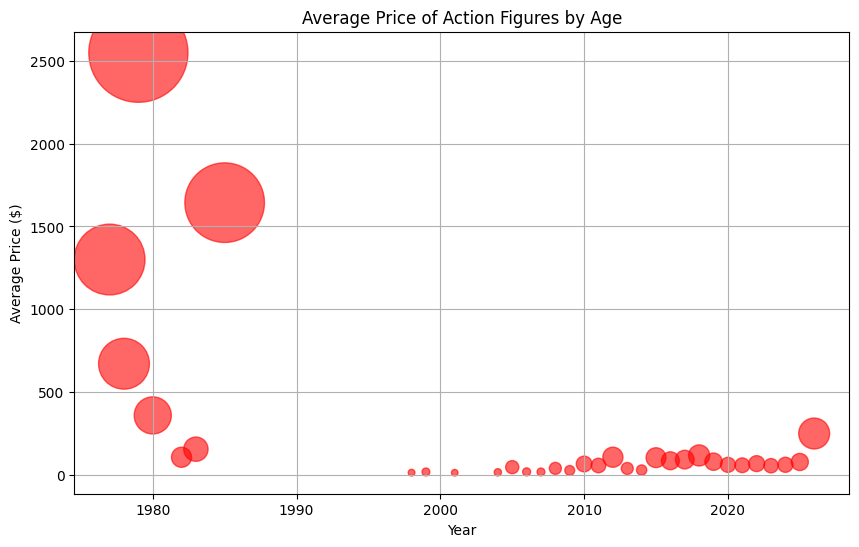

In [40]:
# Time Series Plot: Average Price Over Time
plt.figure(figsize=(10, 6))
average_price_over_time = matched_data_df.groupby('year')['average_price'].mean()
plt.scatter(average_price_over_time.index, average_price_over_time.values, marker='o', s=average_price_over_time.values * 2, alpha=0.6, color='red')
plt.xlabel('Year')
plt.ylabel('Average Price ($)')
plt.title('Average Price of Action Figures by Age')
plt.grid(True)
plt.show()

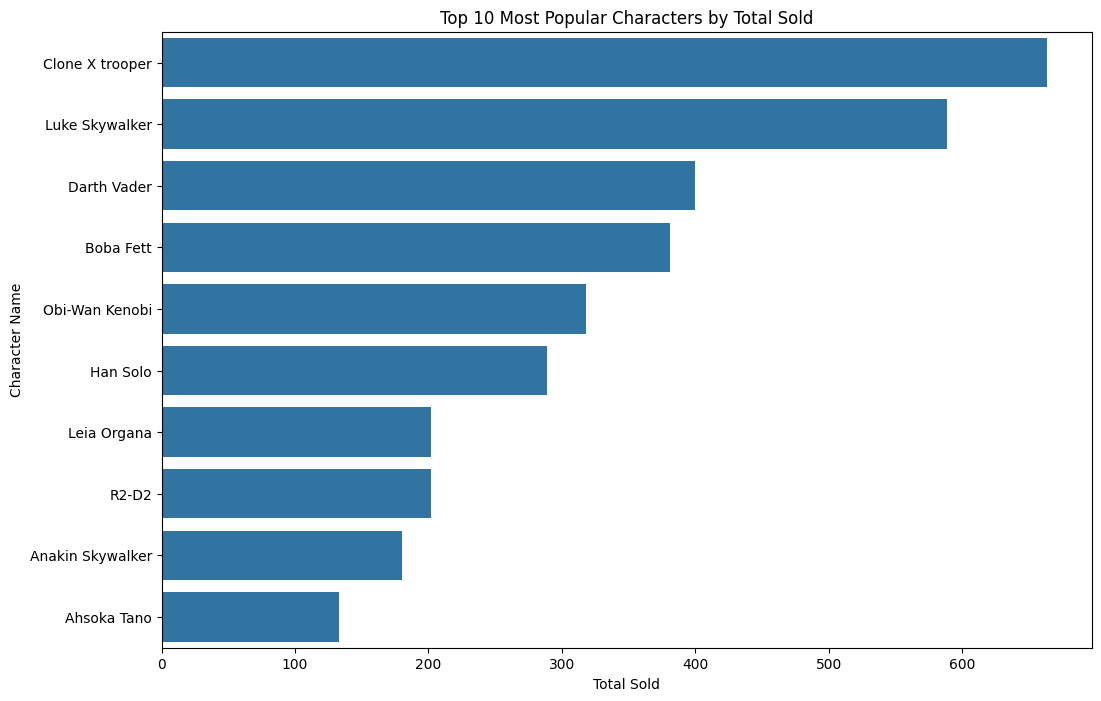

In [41]:
# Bar Chart: Most Popular Characters by Total Sold
plt.figure(figsize=(12, 8))
most_popular_characters = matched_data_df.groupby('matched_character_name')['number_sold'].sum().nlargest(10)
sns.barplot(x=most_popular_characters.values, y=most_popular_characters.index)
plt.xlabel('Total Sold')
plt.ylabel('Character Name')
plt.title('Top 10 Most Popular Characters by Total Sold')
plt.show()

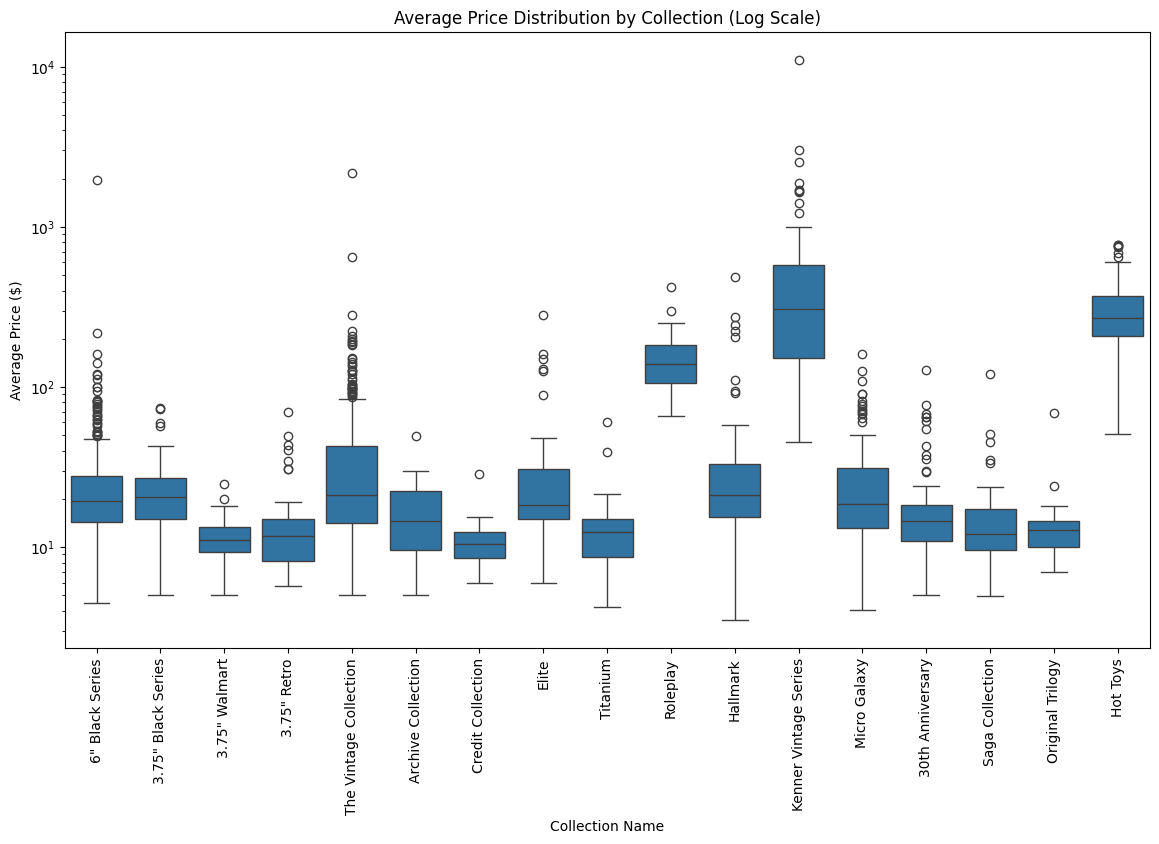

In [42]:
# Box Plot: Price Distribution by Collection on a log scale
plt.figure(figsize=(14, 8))
sns.boxplot(x='collection_name', y='average_price', data=matched_data_df)
plt.yscale('log')
plt.xlabel('Collection Name')
plt.ylabel('Average Price ($)')
plt.title('Average Price Distribution by Collection (Log Scale)')
plt.xticks(rotation=90)
plt.show()

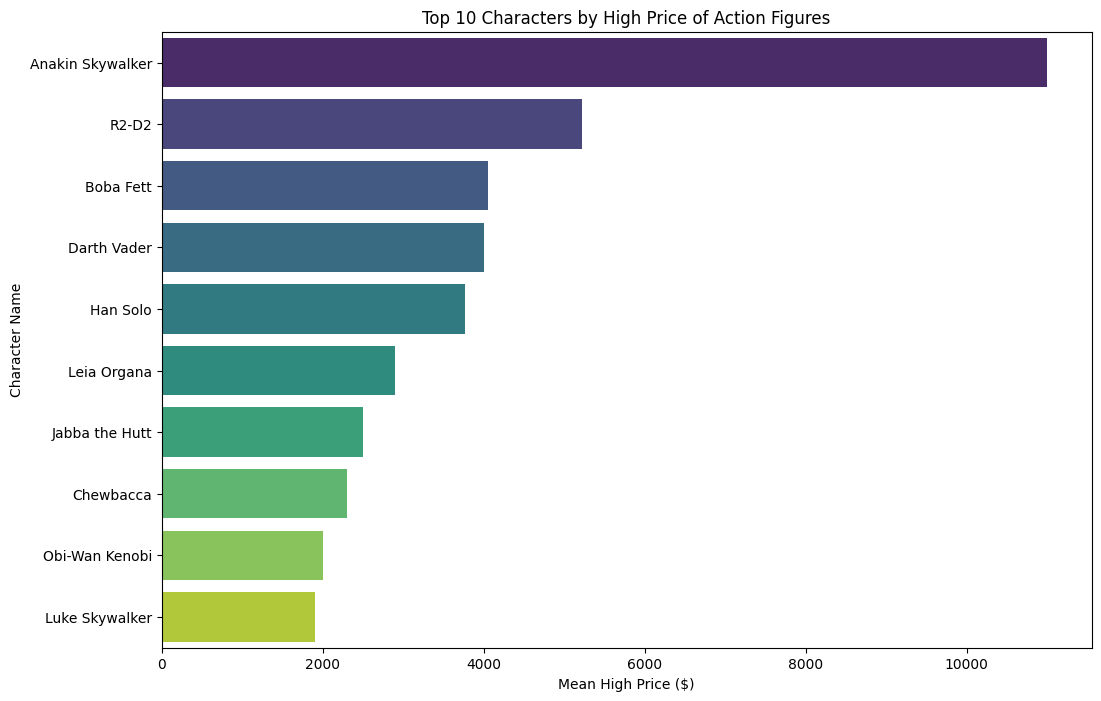

In [43]:
# Scatter Plot: Price vs Number Sold
plt.figure(figsize=(12, 8))
highest_price = matched_data_df.groupby('matched_character_name')['high_price'].max().nlargest(10)
sns.barplot(x=highest_price.values, y=highest_price.index, palette='viridis', hue=highest_price.index, dodge=False, legend=False)
plt.xlabel('Mean High Price ($)')
plt.ylabel('Character Name')
plt.title('Top 10 Characters by High Price of Action Figures')
plt.show()

## Milestone 3 Summary

In Milestone 3, the primary focus was to collect, clean, and analyze data from the actionfigure411.com website, specifically targeting Star Wars action figures. The project involved extensive web scraping using BeautifulSoup, extracting various details such as collection name, figure name, year, retail price, and average price. After gathering the data, several data transformation steps were performed directly within the Jupyter Notebook environment to ensure the dataset was clean and consistent. These steps included renaming columns for uniformity, removing duplicates, converting data types to numerical formats, and handling date-time conversions.

A crucial part of the milestone was matching action figure names to character names using a fuzzy matching approach. This was achieved by using the sparse_dot_topn library to perform a similarity analysis between figure names and character names from a reference dataset. As a result, 1,397 records had matched character names, with a mean similarity score of approximately 0.92, indicating a high degree of match accuracy when one was found.

### Ethical Implications of Data Wrangling

When wrangling the data for this project, several changes were made, including renaming headers, removing duplicates, transforming data types, and conducting fuzzy matching. These transformations aimed to create a clean and usable dataset. However, ethical considerations come into play when altering data. The main risks involve the potential for misrepresentation or unintentional bias introduced during cleaning, such as the elimination of records due to fuzzy matching inaccuracies or incorrect data type conversions. No specific legal or regulatory guidelines apply to this dataset since it is sourced from publicly available information, but ensuring data accuracy and integrity remains essential. The data was acquired ethically by scraping a publicly accessible website without circumventing any restrictions.

To mitigate risks, steps were taken to carefully handle missing or erroneous values and clearly document all assumptions, such as assuming that unmatched records are less relevant and should be removed. Additionally, the fuzzy matching process was validated by setting a similarity threshold to reduce incorrect matches. For transparency, the original HTML files were saved to ensure traceability and reproducibility of the scraping process. Future work could involve consulting with the data source owners or integrating their feedback to ensure data usage aligns with their intent and expectations.

### Next Steps

For the next milestone, I will be working with the star wars API (swapi).  The intent will be to augment the character and action figure datasets with additional information such as year of birth that were not available from the prior two sources.

# Milestone 4 - Connecting to an API/Pulling in the Data and Cleaning/Formatting

Perform at least 5 data transformation and/or cleansing steps to your API data. The below examples are not required - they are just potential transformations you could do. If your data doesn't work for these scenarios, complete different transformations. You can do the same transformation multiple times if needed to clean your data. The goal is a clean dataset at the end of the milestone. As a reminder - you cannot export your API data to CSV to work with it, you must do all the work directly against the API/JSON source.

**Examples:**
* Replace Headers
* Format data into a more readable format
* Identify outliers and bad data
* Find duplicates
* Fix casing or inconsistent values
* Conduct Fuzzy Matching

Make sure you clearly number and label each transformation step (Step #1, Step #2, etc.) in your code and describe what it is doing in 1-2 sentences.

You must submit the following:

* Jupyter Notebook File or PDF of your code with Milestone # listed.
* Each transformation should be labeled with description or what it is doing.
* Human readable dataset after all transformations should be printed at the end of your notebook.
* 1 paragraph of the ethical implications of data wrangling specific to your datasource and the steps you completed answering the following questions:
    * What changes were made to the data?
    * Are there any legal or regulatory guidelines for your data or project topic?
    * What risks could be created based on the transformations done?
    * Did you make any assumptions in cleaning/transforming the data?
    * How was your data sourced / verified for credibility?
    * Was your data acquired in an ethical way?
    * How would you mitigate any of the ethical implications you have identified?

You can submit a Jupyter Notebook or a PDF of your code. If you submit a .py file you need to also include a PDF or attachment of your results.

## Collecting Data from Star Wars Databank API

Hosted at https://starwars-databank.vercel.app, the Star Wars Databank API returns data about characters, creatures, droids, and more from the Star Wars universe.  I will use this API to pull in and clean up data that I populated manually into a CSV file from starwars.com/databank.  Before doing that however, I will also pull in SWAPI.dev data and join it to this data set

### Reusable Functions to pull from starwars-databank-vercel.app

* `fetch_data_from_api` is used to access the endpoint URL
* `collect_all_pages` will loop through all the pages in the endpoint and retrieve the data for that endpoint.

In [44]:
def fetch_data_from_api(endpoint):
    """
    Function to fetch data from the API endpoint.
    :param endpoint: URL of the API endpoint
    :return: JSON data
    """
    response = requests.get(endpoint)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Failed to retrieve data from {endpoint}")
        return None

def collect_all_pages(endpoint):
    """
    Function to collect data from all pages of the API endpoint in a more efficient way by fetching all records in one call.
    :param endpoint: URL of the API endpoint
    :return: List of all records
    """
    response = fetch_data_from_api(endpoint)
    if response and 'info' in response:
        total_records = response['info'].get('total', 10)
        # Modify the endpoint to fetch all data in one call
        updated_endpoint = f"{endpoint}?page=1&limit={total_records}"
        response = fetch_data_from_api(updated_endpoint)
        if response and 'data' in response:
            return response['data']
    return []

### Define Endpoint List

Here I define a list of all of the endpoints available in the `starwars-databank.vercel.app` API.  I will loop through these endpoints to pull all of the data.

In [45]:
# List of endpoints to pull data from
endpoints = {
    'characters': 'https://starwars-databank-server.vercel.app/api/v1/characters',
    'creatures': 'https://starwars-databank-server.vercel.app/api/v1/creatures',
    'droids': 'https://starwars-databank-server.vercel.app/api/v1/droids',
    'locations': 'https://starwars-databank-server.vercel.app/api/v1/locations',
    'organizations': 'https://starwars-databank-server.vercel.app/api/v1/organizations',
    'species': 'https://starwars-databank-server.vercel.app/api/v1/species',
    'vehicles': 'https://starwars-databank-server.vercel.app/api/v1/vehicles'
}

### Make Calls to Endpoints and Retrive Data

* Loop through each endpoint and collect all data
* Combine all the data into a single dataframe
* Sort the dataframe by type and store to a csv as reference

In [46]:
# Loop through each endpoint and collect data for each type
data_dict = {}
for key, endpoint in endpoints.items():
    print(f"Fetching data for {key}...")
    data = collect_all_pages(endpoint)
    if data:
        # Add a column to indicate the type of data
        for record in data:
            record['type'] = key
        data_dict[key] = data

Fetching data for characters...
Fetching data for creatures...
Fetching data for creatures...
Fetching data for droids...
Fetching data for droids...
Fetching data for locations...
Fetching data for locations...
Fetching data for organizations...
Fetching data for organizations...
Fetching data for species...
Fetching data for species...
Fetching data for vehicles...
Fetching data for vehicles...


In [47]:
# Combine all data into a single DataFrame
all_data = []
for data_type, records in data_dict.items():
    all_data.extend(records)

df_all = pd.DataFrame(all_data)

In [48]:
# Sort the data by the 'type' column
df_all = df_all.sort_values(by='type')
# Save the combined data to a single CSV
df_all.to_csv(f"{databank_path}/all_starwars_data.csv", index=False)
print(f"All data saved to {databank_path}/all_starwars_data.csv.")

All data saved to ../data/databank/all_starwars_data.csv.


## Collecting Data from SWAPI.dev

SWAPI.dev is a Star Wars Universe API that is used primarily for tutorial purposes.  For this part, I am going to retrieve all of the Data from the SWAPI.dev API.  Along the way, I will be performing data transformations on the data.

### Reusable Functions for Pulling SWAPI.dev Data

* `fetch_data_from_api` calls the endpoint to retrieve data from (e.g., characters, starships, etc)
* `collect_all_pages` loops through the endpoint to retrieve data from each page.
* `clean_data` is used later to remove key columns from each of the relational dataframes that are not needed after processing

In [49]:
def fetch_data_from_api(endpoint):
    """
    Function to fetch data from the API endpoint.
    :param endpoint: URL of the API endpoint
    :return: JSON data
    """
    response = requests.get(endpoint)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Failed to retrieve data from {endpoint}")
        return None

def collect_all_pages(endpoint):
    """
    Function to collect data from all pages of the API endpoint.
    :param endpoint: URL of the API endpoint
    :return: List of all records
    """
    all_data = []
    while endpoint:
        response = fetch_data_from_api(endpoint)
        if response and 'results' in response:
            all_data.extend(response['results'])
            endpoint = response.get('next')
        else:
            break
    return all_data

def clean_data(record, keys_to_remove):
    """
    Function to clean unwanted keys from a record.
    :param record: The dictionary representing the record
    :param keys_to_remove: List of keys to remove from the record
    """
    for key in keys_to_remove:
        if key in record:
            del record[key]
    return record

### Define Endpoint List

In [50]:
# List of endpoints to pull data from
endpoints = {
    'people': 'https://swapi.dev/api/people/',
    'planets': 'https://swapi.dev/api/planets/',
    'films': 'https://swapi.dev/api/films/',
    'species': 'https://swapi.dev/api/species/',
    'vehicles': 'https://swapi.dev/api/vehicles/',
    'starships': 'https://swapi.dev/api/starships/'
}

### Make Calls to Endpoints and Retrieve Data

* Initialize Data Stores for relationships
* Loop Through Each Endpoint and Retrieve Data
  * While Looping Through Endpoints, create association tables (bridge / relationship tables)
* Remove bridge columns from dataframes
* Write data and bridge tables out to CSV for reference

In [51]:
data_dict = {}
relations = {
    'people_films': set(),
    'people_species': set(),
    'people_vehicles': set(),
    'people_starships': set(),
    'planets_people': set(),
    'films_planets': set(),
    'films_starships': set(),
    'films_vehicles': set(),
    'films_species': set()
}

In [52]:
# Loop through each endpoint and collect data for each type
for key, endpoint in endpoints.items():
    print(f"Fetching data for {key}...")
    data = collect_all_pages(endpoint)
    if data:
        # Save relationship records for people before cleaning
        if key == 'people':
            for person in data:
                person_id = person['url']
                for film in person.get('films', []):
                    relations['people_films'].add((person_id, film))
                for species in person.get('species', []):
                    relations['people_species'].add((person_id, species))
                for vehicle in person.get('vehicles', []):
                    relations['people_vehicles'].add((person_id, vehicle))
                for starship in person.get('starships', []):
                    relations['people_starships'].add((person_id, starship))
        # Save relationship records for planets before cleaning
        elif key == 'planets':
            for planet in data:
                planet_id = planet['url']
                for resident in planet.get('residents', []):
                    relations['planets_people'].add((planet_id, resident))
                for film in planet.get('films', []):
                    relations['films_planets'].add((planet_id, film))
        # Save relationship records for films before cleaning
        elif key == 'films':
            for film in data:
                film_id = film['url']
                for character in film.get('characters', []):
                    relations['people_films'].add((character, film_id))
                for planet in film.get('planets', []):
                    relations['films_planets'].add((planet, film_id))
                for starship in film.get('starships', []):
                    relations['films_starships'].add((film_id, starship))
                for vehicle in film.get('vehicles', []):
                    relations['films_vehicles'].add((film_id, vehicle))
                for species in film.get('species', []):
                    relations['films_species'].add((film_id, species))
        # Save relationship records for species before cleaning
        elif key == 'species':
            for species in data:
                species_id = species['url']
                for person in species.get('people', []):
                    relations['people_species'].add((person, species_id))
                for film in species.get('films', []):
                    relations['films_species'].add((film, species_id))
        # Save relationship records for vehicles before cleaning
        elif key == 'vehicles':
            for vehicle in data:
                vehicle_id = vehicle['url']
                for film in vehicle.get('films', []):
                    relations['films_vehicles'].add((film, vehicle_id))
                for pilot in vehicle.get('pilots', []):
                    relations['people_vehicles'].add((pilot, vehicle_id))
        # Save relationship records for starships before cleaning
        elif key == 'starships':
            for starship in data:
                starship_id = starship['url']
                for film in starship.get('films', []):
                    relations['films_starships'].add((film, starship_id))
                for pilot in starship.get('pilots', []):
                    relations['people_starships'].add((pilot, starship_id))
                    
        # Clean data by removing relational keys
        if key == 'people':
            keys_to_remove = ['films', 'species', 'vehicles', 'starships']
        elif key == 'planets':
            keys_to_remove = ['residents', 'films']
        elif key == 'films':
            keys_to_remove = ['characters', 'planets', 'starships', 'vehicles', 'species']
        elif key == 'species':
            keys_to_remove = ['people', 'films']
        elif key == 'vehicles':
            keys_to_remove = ['films', 'pilots']
        elif key == 'starships':
            keys_to_remove = ['films', 'pilots']
        else:
            keys_to_remove = []

        data_dict[key] = [clean_data(record, keys_to_remove) for record in data]

Fetching data for people...
Fetching data for planets...
Fetching data for planets...
Fetching data for films...
Fetching data for films...
Fetching data for species...
Fetching data for species...
Fetching data for vehicles...
Fetching data for vehicles...
Fetching data for starships...
Fetching data for starships...


In [53]:
# Convert sets to lists of dictionaries
for relation in relations:
    relations[relation] = [dict(zip(['entity1', 'entity2'], item)) for item in relations[relation]]

# Create dataframes for each collected type and relationship bridge tables
dataframes = {}
for data_type, records in data_dict.items():
    dataframes[data_type] = pd.DataFrame(records)

# Create relational dataframes for bridge tables
for relation, records in relations.items():
    dataframes[relation] = pd.DataFrame(records)

In [54]:
# Saving all dataframes as CSVs
for name, df in dataframes.items():
    df.to_csv(f"{csv_path}/{name}.csv", index=False)
    print(f"{csv_path}/{name} data saved to CSV.")

print("Data collection and relational bridge table creation complete.")


../data/csv/people data saved to CSV.
../data/csv/planets data saved to CSV.
../data/csv/films data saved to CSV.
../data/csv/species data saved to CSV.
../data/csv/vehicles data saved to CSV.
../data/csv/starships data saved to CSV.
../data/csv/people_films data saved to CSV.
../data/csv/people_species data saved to CSV.
../data/csv/people_vehicles data saved to CSV.
../data/csv/people_starships data saved to CSV.
../data/csv/planets_people data saved to CSV.
../data/csv/films_planets data saved to CSV.
../data/csv/films_starships data saved to CSV.
../data/csv/films_vehicles data saved to CSV.
../data/csv/films_species data saved to CSV.
Data collection and relational bridge table creation complete.


## Merge starwars-databank and SWAPI Data Sets

Here we are going to use Fuzzy Match and perform a match between the starwars-databank.vercel.app data and the swapi.dev data.  There are only about 82 characters in the swapi.dev so this data did not turn out to be as helpful as I had hoped, however, I will keep it in to augment other character related data.

### Reusable Functions for Merge

* `fuzzy_match_names` creates scroes for matching the datasets on name.  Set 90% threshold for match to reduce some incorrect joins.

In [55]:
# Define a function to match names with fuzzy logic
def fuzzy_match_names(target_list, reference_list, threshold=90):
    matches = []
    for name in target_list:
        best_match, score = process.extractOne(name, reference_list)
        if score >= threshold:
            matches.append((name, best_match, score))
    return matches

### Create Dataframes for Merge

* Get character dataframe from starwars-databank API
* Get people dataframe from swapi.dev API

In [56]:
# Get all_starwars_data dataframe
all_starwars_data = df_all
# Filter to just character data
character_data = all_starwars_data[all_starwars_data['type'] == 'characters']

# Get people data from swapi.dev
people_data = dataframes['people']


### Apply Fuzzy Matching

* prepare columns for matching
* Apply matching function
* Create dataframe from matched results

In [57]:
# Prepare for fuzzy matching
character_names = character_data['name'].tolist()
people_names = people_data['name'].tolist()

# Apply fuzzy matching
matched_names = fuzzy_match_names(character_names, people_names)

# Create a DataFrame from the matched results
matched_df = pd.DataFrame(matched_names, columns=['character_name', 'people_name', 'score'])

### Merge The Data Frames

* Merge matched dataframe with character_data dataframe
* Merge the people_data to the character data on matched names
* Rename columns for ease of use and understanding
* Output Data to CSV for reference

In [58]:
# Merge the matched DataFrame with character_data
character_data = pd.merge(character_data, matched_df, left_on='name', right_on='character_name', how='left')

# Perform the left join with people_data
merged_data = pd.merge(character_data, people_data, left_on='people_name', right_on='name', how='left', suffixes=('_character', '_people'))

# Keep columns for matched names and scores
merged_data = merged_data.rename(columns={'name_people': 'matched_name', 'score': 'fuzzy_score'})

In [59]:
# rename columns
merged_data = merged_data.rename(columns={
    '_id': 'databank_id',
    '__v': 'databank_version_num',
    'url': 'swapi_url'
})

In [60]:
# Extract year and generation from birth_year column
merged_data['year'] = merged_data['birth_year'].str.extract(r'(\d+)').astype(float)
merged_data['generation'] = merged_data['birth_year'].str.extract(r'([A-Z]+)')

In [61]:
# Save to a new CSV if needed
merged_data.to_csv(f"{csv_path}/merged_fuzzy_characters_data_left_join.csv", index=False)

print("Fuzzy matching and data merge complete.")


Fuzzy matching and data merge complete.


In [62]:
# Display merged data
display(merged_data.sample(sample_size, random_state=random_state))

,databank_id,name_character,description,image,databank_version_num,type,character_name,people_name,fuzzy_score,matched_name,...,skin_color,eye_color,birth_year,gender,homeworld,created,edited,swapi_url,year,generation
760,64292927021f17e13fbc1fb6,Gorga the Hutt,"One of the ruling members of the Hutt Council,...",https://lumiere-a.akamaihd.net/v1/images/datab...,0,characters,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
884,64292927021f17e13fbc1f40,Desix,"At the dawn of the Empire, many worlds remain ...",https://lumiere-a.akamaihd.net/v1/images/desix...,0,characters,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
938,64292927021f17e13fbc1f90,Gamorrean Guards,Once loyal to Jabba the Hutt and later Bib For...,https://lumiere-a.akamaihd.net/v1/images/gamor...,0,characters,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
901,64292927021f17e13fbc1f51,Dormé,"Despite no longer being Naboo’s queen, Padmé A...",https://lumiere-a.akamaihd.net/v1/images/dorme...,0,characters,Dormé,Dormé,100.0,Dormé,...,light,brown,unknown,female,https://swapi.dev/api/planets/8/,2014-12-20T16:49:14.640000Z,2014-12-20T21:17:50.460000Z,https://swapi.dev/api/people/66/,NaN,NaN
622,64292927021f17e13fbc1e76,ARC Trooper Fives,"Also known as CT-27-5555, Fives trained with D...",https://lumiere-a.akamaihd.net/v1/images/datab...,0,characters,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Milestone 4 Summary

In this milestone, I pulled data from two Star Wars related APIs: starwars-databank.vercel.app and swapi.dev.  These APIs hosted information about various characters, locations, vehicles, etc in the Star Wars universe.  While pulling the data, I attempting to demonstrate understanding of using APIs such as:

* Connecting to the API use requests library
* Paging through Data using next
* Updating URL Parameters to obtain data from different endpoints

In addition, I performed various transforms on the data including:

* splitting swapi.dev responses into association tables (csv) and data tables
* dropping columns of data that were not needed after creating association tables 
* performing fuzzy matching to merge the starwars-databank and swapi dataframes
* renaming columns
* Creating new features (e.g., year of birth, generation of birth)

In regards to ethical considerations, all information was sourced from publicly available APIs.  The sources of these APIs are documented above.  The data collected is on fictional characters in the Star Wars universe canon and there I did not perform any data masking or tokenization.  The data was aquired through standard python libraries according to the terms on the websites that provide the APIs.  I see no outstanding ethical considerations needing further remediation.

### Next Steps

For the next milestone, I will be creating a Star Wars character database from the information collected during the prior milestone.  In that exercise, I will create relational data tables to host the character data and link it to associated action figure data.  I will also provide connectivity to additional supporting detail in the web scraping performed from starwars.com.  



# Milestone 5 - Merging the Data and Storing in a Database / Visualizing Data

Now that you have cleaned and transformed your 3 datasets, you need to load them into a database. You can choose what kind of database (SQLLite or MySQL, Postgre SQL are all free options). You will want to load each dataset into SQL Lite as an individual table and then you must join the datasets together with SQL joins into 1 dataset.

Once all the data is merged together in your database, create 5 visualizations that demonstrate the data you have cleansed. You should have at least 2 visualizations that have data from more than one source, using SQL joins (meaning, if you have 3 tables, you must have visualizations that span across 2 of the tables – you are also welcome to use your consolidated dataset that you created in the previous step, if you do that, you have met this requirement).

For the visualization portion of the project, you are welcome to use a python library like Matplotlib, Seaborn, or an R package ggPlot2, Plotly, or Tableau/PowerBI.

PowerBI is a free tool that could be used – Tableau only has a free web author. If you use Tableau/PowerBI you need to submit a PDF with your assignment vs the Tableau/PowerBI file.

Clearly label each visualization. Submit your code for merging and storing in the database, with your code for the visualizations along with a 250-500-word summary of what you learned and had to do to complete the project In your write-up, make sure to address the ethical implications of cleansing data and your project topic. You can submit a Jupyter Notebook or a PDF of your code. If you submit a .py file you need to also include a PDF or attachment of your results.

You must submit the following:
* Jupyter Notebook File or PDF of your code with Milestone # listed.
* Each step and visualization should be clearly labeled.
* Human readable dataset after all transformations should be printed at the end of your notebook.
* 250-500 word summary of what you learned and a summary of the ethical implications answering the following questions:
    * What changes were made to the data?
    * Are there any legal or regulatory guidelines for your data or project topic?
    * What risks could be created based on the transformations done?
    * Did you make any assumptions in cleaning/transforming the data?
    * How was your data sourced / verified for credibility?
    * Was your data acquired in an ethical way?
    * How would you mitigate any of the ethical implications you have identified?

**Remember** – your GitHub repository can act as a portfolio for potential employers! I would highly suggest using this to submit your work, so you can fill it with good content that demonstrates the projects you are working on!

## Reusable Functions

* **create_visualizations** creates visualizations from passed in parameters
* **load_and_store_csv_to_db** takes in csv details, creates database tables, loads data to tables, then extracts and returns data to the caller

In [63]:
def create_visualization(data, plot_func, title, xlabel, ylabel, save_path, **kwargs):
    """
    Create a reusable function for visualizations.
    
    Args:
    data (DataFrame): The dataset to visualize.
    plot_func (function): The seaborn plotting function to use.
    title (str): The title of the plot.
    xlabel (str): The x-axis label.
    ylabel (str): The y-axis label.
    save_path (str): Path to save the plot.
    kwargs: Additional keyword arguments to pass to the plotting function.
    """
    plt.figure(figsize=(10, 6))
    plot_func(data=data, **kwargs)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.subplots_adjust(top=0.9, bottom=0.1)
    plt.savefig(save_path)
    
def load_and_store_csv_to_db(file_path, db_path, table_name):
    """
    Load a CSV file into a pandas DataFrame, connect to an SQLite database, 
    create a new table, and populate it with the dataset.
    
    Args:
    file_path (str): Path to the CSV file to load.
    db_path (str): Path to the SQLite database.
    table_name (str): Name of the table to create in the database.
    
    Returns:
    tuple: Schema and preview of the newly created table.
    """
    # Load the dataset
    df = pd.read_csv(file_path)
    
    # Connect to SQLite database and populate the table
    with sqlite3.connect(db_path) as conn:
        df.to_sql(table_name, conn, if_exists='replace', index=False)
        schema = pd.read_sql_query(f"PRAGMA table_info({table_name});", conn)
        table_preview = pd.read_sql_query(f"SELECT * FROM {table_name} LIMIT 5;", conn)
    
    return schema, table_preview

# File paths and database path
db_path = f"{database_path}/star_wars_project.db"

## Load Milestone 2 Data to DB

* Load the milestone 2 csv file (character_appearances_data.csv) and store in database
* Display schema of table
* Display first few rows of table

In [64]:
# Load character appearances data
character_appearances_file = f"{csv_path}/character_appearances_data.csv"
character_appearances_schema, character_appearances_preview = load_and_store_csv_to_db(character_appearances_file, db_path, 'character_appearances')

In [65]:
# Display schema of character_appearances table
display(character_appearances_schema)

,cid,name,type,notnull,dflt_value,pk
0,0,id,TEXT,0,None,0
1,1,name,TEXT,0,None,0
2,2,gender,TEXT,0,None,0
3,3,species,TEXT,0,None,0
4,4,dimension type,TEXT,0,None,0
5,5,dimension size,TEXT,0,None,0
6,6,character databank link,TEXT,0,None,0
7,7,media type,TEXT,0,None,0
8,8,media key,TEXT,0,None,0
9,9,appearance name,TEXT,0,None,0


In [66]:
# Display first few rows of character appearances
display(character_appearances_preview)

,id,name,gender,species,dimension type,dimension size,character databank link,media type,media key,appearance name
0,616b34b4f2d1d492a01ad05b,"""Hyper"" Rod",unknown,unknown,None,unknown,https://www.starwars.com/databank/hyper-rod,series,star-wars-the-bad-batch,Star Wars: The Bad Batch
1,616b34b7e840b492a01ad05b,"""Quick-Draw"" Quasar",unknown,unknown,None,unknown,https://www.starwars.com/databank/quick-draw-q...,series,star-wars-the-bad-batch,Star Wars: The Bad Batch
2,616b34bae19c8492a01ad05b,"""Steel Claw"" Kane",unknown,nikto,None,unknown,https://www.starwars.com/databank/steel-claw-kane,series,star-wars-the-bad-batch,Star Wars: The Bad Batch
3,616b34b66ea8f492a01ad05b,"""The Trickster"" Flash Raktor",unknown,unknown,None,unknown,https://www.starwars.com/databank/the-trickste...,series,star-wars-the-bad-batch,Star Wars: The Bad Batch
4,616b31bd480c1492a01ad05b,2BR-NTB,unknown,unknown,None,unknown,https://www.starwars.com/databank/2br-ntb,series,star-wars-resistance,Star Wars Resistance


## Load Milestone 3 Data to DB

* Load the milestone 3 csv file (action_figure_prices_transformed.csv) and store in database
* Display schema of table
* Display first few rows of table

In [67]:
# Load action figure prices data
action_figure_path = f"{csv_path}/action_figure_prices_transformed.csv"
action_figure_schema, action_figure_preview = load_and_store_csv_to_db(action_figure_path, db_path, 'action_figure_prices')

In [68]:
# Display action figure table schema
display(action_figure_schema)

,cid,name,type,notnull,dflt_value,pk
0,0,collection_order,INTEGER,0,None,0
1,1,collection_name,TEXT,0,None,0
2,2,table_order,INTEGER,0,None,0
3,3,table_group,TEXT,0,None,0
4,4,web_table_id,TEXT,0,None,0
5,5,figure_order,INTEGER,0,None,0
6,6,figure_number,TEXT,0,None,0
7,7,figure_name,TEXT,0,None,0
8,8,wave,TEXT,0,None,0
9,9,year,INTEGER,0,None,0


In [69]:
# Display first few rows of action figure table data
display(action_figure_preview)

,collection_order,collection_name,table_order,table_group,web_table_id,figure_order,figure_number,figure_name,wave,year,number_sold,retail_price,average_price,difference,high_price,unique_id,detail_reference,year_datetime,matched_character_name,similarity_score
0,1,"6"" Black Series",1,Orange Wave 2013,groupTable1,1,01,Luke Skywalker (X-Wing Pilot),1,2013,7,19.99,19.74,-0.25,30.00,697efbd72af78107269fbb094b02601b,https://www.actionfigure411.com/star-wars/6-bl...,2013-01-01,Luke Skywalker,0.830591
1,1,"6"" Black Series",1,Orange Wave 2013,groupTable1,2,02,Darth Maul ( $-5.96),1,2013,14,19.99,33.17,13.18,70.00,6268220933c0c52fdb4379aea3b1d311,https://www.actionfigure411.com/star-wars/6-bl...,2013-01-01,Maul,0.753451
2,1,"6"" Black Series",1,Orange Wave 2013,groupTable1,4,04,R2-D2,1,2013,11,19.99,46.85,26.86,55.00,e77aa955b579601d0bc73d2013d59322,https://www.actionfigure411.com/star-wars/6-bl...,2013-01-01,R2-D2,1.000000
3,1,"6"" Black Series",1,Orange Wave 2013,groupTable1,6,06,Boba Fett,2,2013,1,19.99,24.99,5.00,24.99,f8b296adbceeb548aec2479d0d9a7250,https://www.actionfigure411.com/star-wars/6-bl...,2013-01-01,Boba Fett,1.000000
4,1,"6"" Black Series",1,Orange Wave 2013,groupTable1,7,07,Greedo,2,2013,4,19.99,30.00,10.01,32.00,a54b9af652cef9d0b8d6b5b316a5f8a3,https://www.actionfigure411.com/star-wars/6-bl...,2013-01-01,Greedo,1.000000


## Load Milestone 4 Data to DB

* Load the milestone 4 csv file (merged_fuzzy_characters_data_left_join.csv) and store in database
* Display schema of table
* Display first few rows of table

In [71]:
# Load merged fuzzy characters data
merged_fuzzy_file = f"{csv_path}/merged_fuzzy_characters_data_left_join.csv"
merged_fuzzy_schema, merged_fuzzy_preview = load_and_store_csv_to_db(merged_fuzzy_file, db_path, 'merged_fuzzy_characters')

In [72]:
# Display fuzzy characters table schema
display(merged_fuzzy_schema)

,cid,name,type,notnull,dflt_value,pk
0,0,databank_id,TEXT,0,None,0
1,1,name_character,TEXT,0,None,0
2,2,description,TEXT,0,None,0
3,3,image,TEXT,0,None,0
4,4,databank_version_num,INTEGER,0,None,0
5,5,type,TEXT,0,None,0
6,6,character_name,TEXT,0,None,0
7,7,people_name,TEXT,0,None,0
8,8,fuzzy_score,REAL,0,None,0
9,9,matched_name,TEXT,0,None,0


In [73]:
# Display first few rows of fuzzy characters table data
display(merged_fuzzy_preview)

,databank_id,name_character,description,image,databank_version_num,type,character_name,people_name,fuzzy_score,matched_name,...,skin_color,eye_color,birth_year,gender,homeworld,created,edited,swapi_url,year,generation
0,64292927021f17e13fbc1e46,"""Hyper"" Rod","In his specially-modified Seven Deuce Blaster,...",https://lumiere-a.akamaihd.net/v1/images/hyper...,0,characters,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,64292927021f17e13fbc20c1,Onaconda Farr,"The Senator from Rodia, Onaconda Farr had long...",https://lumiere-a.akamaihd.net/v1/images/onaco...,0,characters,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,64292927021f17e13fbc20c2,Onca,"Together with his brother Bulduga, Onca was pa...",https://lumiere-a.akamaihd.net/v1/images/acw_i...,0,characters,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,64292927021f17e13fbc20c3,Oniho Zaya,Oniho Zaya lives in the fathier stables of the...,https://lumiere-a.akamaihd.net/v1/images/tlj-d...,0,characters,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,64292927021f17e13fbc20c4,Oola,"A green-skinned Twi'lek, Oola was one of Jabba...",https://lumiere-a.akamaihd.net/v1/images/oola-...,0,characters,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


## Join All Tables of Data

* Perform the join
* Save data to file for future reference
* Display first few rows of joined data

In [74]:
# Reconnect to SQLite database for the updated join
conn = sqlite3.connect(db_path)

# Updated SQL query with correct handling of columns with spaces
query_corrected_full_join = """
SELECT 
    af.*,
    ca.name AS character_name,
    ca.gender AS character_gender,
    ca.species AS character_species,
    ca."dimension type" AS character_dimension_type,
    ca."dimension size" AS character_dimension_size,
    ca."character databank link" AS databank_link,
    ca."media type" AS character_media_type,
    ca."media key" AS character_media_key,
    ca."appearance name" AS character_appearance_name,
    mfc.description AS character_description,
    mfc.image AS character_image,
    mfc.databank_version_num,
    mfc.type AS character_type,
    mfc.people_name,
    mfc.fuzzy_score,
    mfc.height,
    mfc.mass,
    mfc.hair_color,
    mfc.skin_color,
    mfc.eye_color,
    mfc.birth_year,
    mfc.homeworld,
    mfc.created,
    mfc.edited,
    mfc.swapi_url,
    mfc.year AS character_year,
    mfc.generation
FROM action_figure_prices af
LEFT JOIN character_appearances ca ON af.matched_character_name = ca.name
LEFT JOIN merged_fuzzy_characters mfc ON ca.name = mfc.name_character;
"""

# Execute the corrected query
corrected_joined_data = pd.read_sql_query(query_corrected_full_join, conn)

# Close the SQLite connection
conn.close()

In [75]:
# Save the corrected joined dataset to a CSV file
corrected_joined_data_path = '../data/csv/corrected_full_joined_star_wars_dataset.csv'
corrected_joined_data.to_csv(corrected_joined_data_path, index=False)

In [76]:
# Display the corrected joined dataset to the user
display(corrected_joined_data.sample(sample_size, random_state=random_state))

,collection_order,collection_name,table_order,table_group,web_table_id,figure_order,figure_number,figure_name,wave,year,...,hair_color,skin_color,eye_color,birth_year,homeworld,created,edited,swapi_url,character_year,generation
12699,17,Hot Toys,69,Action Figures,groupTable499,2831,MMS 699,Darth Vader (ROTJ),None,2023,...,none,white,yellow,41.9BBY,https://swapi.dev/api/planets/1/,2014-12-10T15:18:20.704000Z,2014-12-20T21:17:50.313000Z,https://swapi.dev/api/people/4/,41.0,BBY
4814,5,The Vintage Collection,19,The Vintage Collection Action Figures,groupTable83,1051,VC 98,Grand Moff Tarkin,14,2012,...,None,None,None,None,None,None,None,None,NaN,None
3038,2,"3.75"" Black Series",13,3.75 Orange 2013-2014,groupTable16,728,09,R2-D2,2,2013,...,None,"white, blue",red,33BBY,https://swapi.dev/api/planets/8/,2014-12-10T15:11:50.376000Z,2014-12-20T21:17:50.311000Z,https://swapi.dev/api/people/3/,33.0,BBY
1355,1,"6"" Black Series",4,Galaxy,groupTable112,366,REB 06,Sabine Wren,Fan,2020,...,None,None,None,None,None,None,None,None,NaN,None
4462,5,The Vintage Collection,19,The Vintage Collection Action Figures,groupTable83,969,VC 35,Mace Windu (Reissue),None,2022,...,none,dark,brown,72BBY,https://swapi.dev/api/planets/42/,2014-12-20T10:12:30.846000Z,2014-12-20T21:17:50.420000Z,https://swapi.dev/api/people/51/,72.0,BBY


## Visualize Joined Data

* Visualize Average Price by Gender
* Visualize Average vs High Price by Collection Name
* Visualize Count of Figures by Gender and Year (spans milestone 2 and 3 datasets)
* Visualize Top Characters by Average Price (spans milestone 2 and 3 datasets)
* Visualize Height vs Average Price by Gender (spans all milestone datasets)

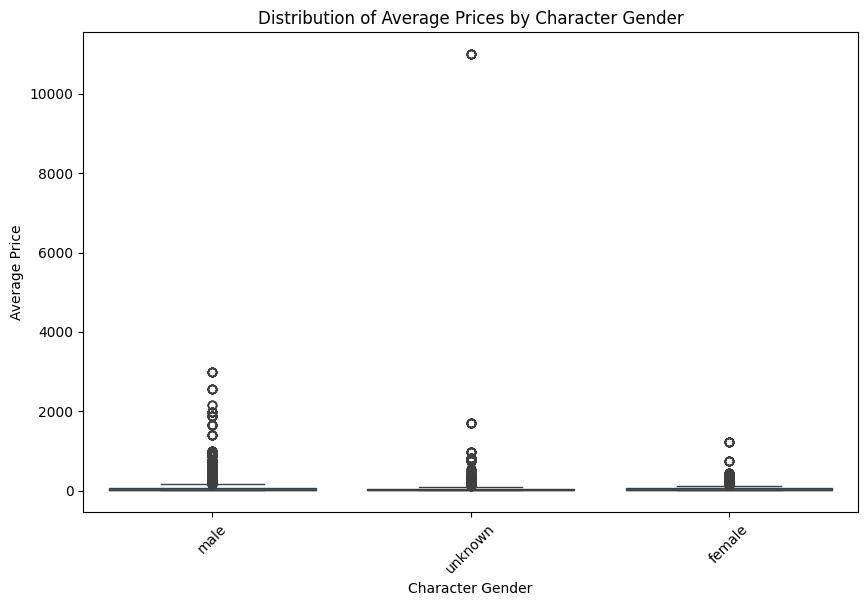

In [77]:
# Distribution of Averages Prices by Gender
os.makedirs('../data/visualizations/', exist_ok=True)
create_visualization(
    data=corrected_joined_data,
    plot_func=sns.boxplot,
    title='Distribution of Average Prices by Character Gender',
    xlabel='Character Gender',
    ylabel='Average Price',
    save_path=f"{visualizations_path}/avg_price_by_gender.png",
    x='character_gender',
    y='average_price'
)


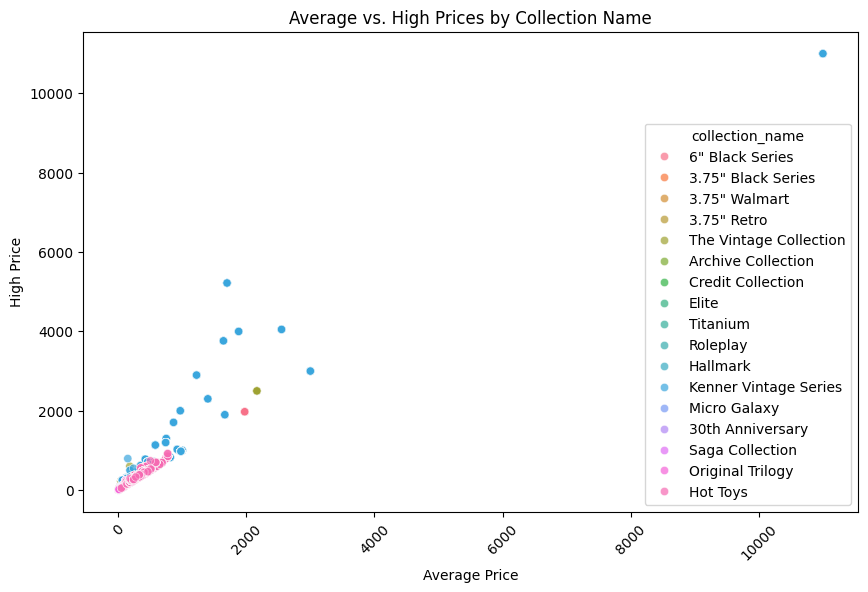

In [78]:
# Average vs High Prices by Collection Name
create_visualization(
    data=corrected_joined_data,
    plot_func=sns.scatterplot,
    title='Average vs. High Prices by Collection Name',
    xlabel='Average Price',
    ylabel='High Price',
    save_path=f"{visualizations_path}/avg_vs_high_price_by_species.png",
    x='average_price',
    y='high_price',
    hue='collection_name',
    alpha=0.7
)

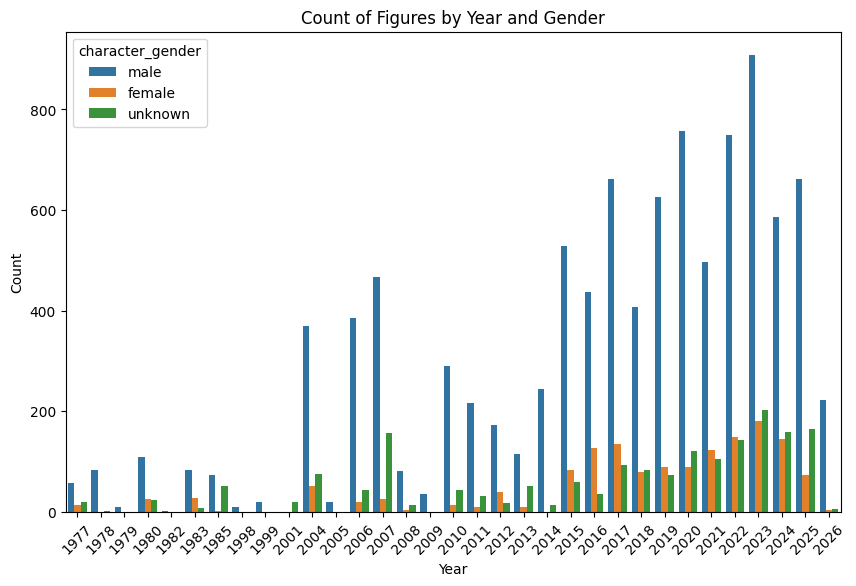

In [79]:
create_visualization(
    data=corrected_joined_data,
    plot_func=sns.countplot,
    title='Count of Figures by Year and Gender',
    xlabel='Year',
    ylabel='Count',
    save_path='../data/visualizations/count_by_year_and_gender.png',
    x='year',
    hue='character_gender',
    order=sorted(corrected_joined_data['year'].dropna().unique())
)

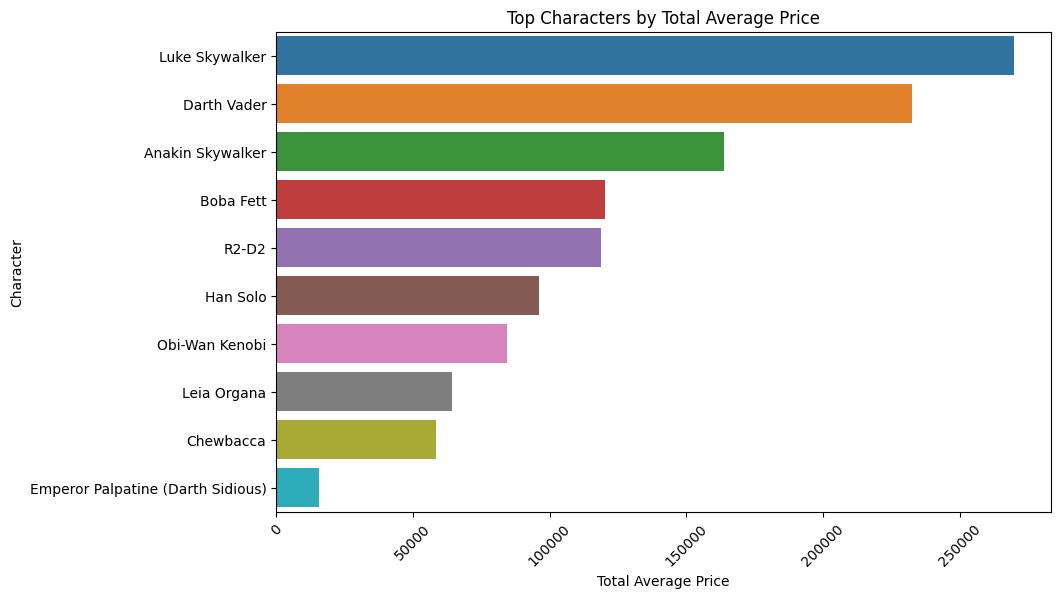

In [80]:
# Top Characters by Total Average Price
top_characters = corrected_joined_data.groupby('character_name')['average_price'].sum().nlargest(10).reset_index()
create_visualization(
    data=top_characters,
    plot_func=sns.barplot,
    title='Top Characters by Total Average Price',
    xlabel='Total Average Price',
    ylabel='Character',
    save_path=f"{visualizations_path}/top_characters_avg_price.png",
    x='average_price',
    y='character_name',
    hue='character_name', legend=False
)

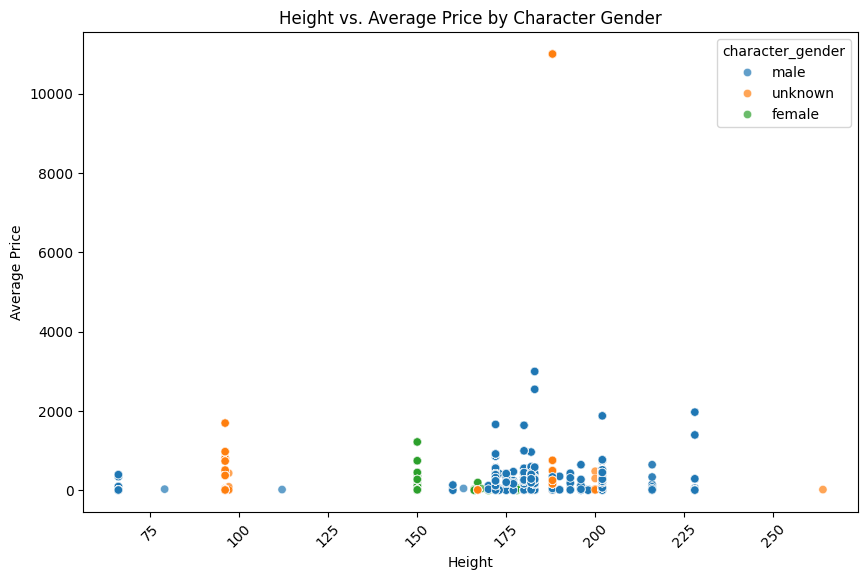

In [81]:
# Height vs. Average Price by Character Gender
create_visualization(
    data=corrected_joined_data,
    plot_func=sns.scatterplot,
    title='Height vs. Average Price by Character Gender',
    xlabel='Height',
    ylabel='Average Price',
    save_path=f"{visualizations_path}/height_vs_avg_price_by_gender.png",
    x='height',
    y='average_price',
    hue='character_gender',
    alpha=0.7
)

## Summary of Milestone 5
In this milestone, I created database tables to host the data from the datasets created in the previous milestones.  While possible to use more complex methods, I took the approach of writing all of the datasets to CSVs and then loading the CSV files as tables into SQL Lite.

After loading the datasets into SQL Lite, I created a dataset which joined all of the table data together creating a larger dataset which I used for visualizations.  For this milestone I attempted to create visualizations that spanned multiple datasets with some using 2 datasets and one using all three datasets.

In regards to ethical considerations, all information was sourced from publicly available APIs.  The sources of these datasets are documented abin the respsective milestone sections along with the ethical considerations for each.  The data collected is on fictional characters in the Star Wars universe canon and there I did not perform any data masking or tokenization.  The data was aquired through standard python libraries according to the terms on the websites that provide the APIs.  I see no outstanding ethical considerations needing further remediation.

# Project Summary

This project involved five milestones, each focusing on different aspects of data integration, transformation, and analysis using Star Wars-related datasets. The goal was to effectively merge and visualize information gathered from a variety of sources, showcasing skills in data wrangling, API handling, web scraping, and database management.

## Overview of Milestones
**Milestone 1** required identifying three data sources of different types—CSV, website, and API—that related to the Star Wars universe. This was particularly challenging as several websites with relevant data had associated costs that were prohibitive for an academic project. Ultimately, freely available sources were used to gather sufficient information to proceed.

**Milestone 2** focused on CSV file data cleaning. This included cleaning up character names, standardizing field values, handling missing values, creating new features, and joining multiple CSVs to create a consolidated dataset for further analysis. The primary challenge here was ensuring consistency across all datasets, especially with varying formats and missing values.

**Milestone 3** involved web scraping to pull data from a website table. This milestone required significant transformations, such as replacing headers, handling duplicate records, converting data types, and using fuzzy matching to align character names between scraped data and previously collected CSV data. Fuzzy matching enabled successful joins but introduced the risk of incorrect matches.

**Milestone 4** required pulling data from APIs, which included handling errors such as unavailable endpoints. Fortunately, most of the data retrieved was in good shape, though additional cleaning was necessary to align it with other datasets. Error handling was implemented to ensure the robustness of data collection and mitigate any interruptions in the data pipeline.

**Milestone 5** involved writing all the cleaned and transformed data into an SQLite database, joining the datasets together, and then visualizing the results. This step required SQL joins to create a unified dataset and developing multiple visualizations to illustrate insights drawn from the merged data.  The visualizations created in Milestone 5 revealed patterns in action figure pricing, character attributes, and other key metrics. For instance, certain character traits correlated with higher action figure values, providing insight into collector preferences.

## Legal, Ethical, and Credibility Consideration of Outputs
**Legal and Regulatory Guidelines**: Given that the data was sourced from public sources, there were no explicit legal concerns, but ethical usage was paramount. Using web-scraped data risks violating terms of service, so ensuring compliance with usage agreements and best practices was a priority.

**Risks Created by Transformations**: Data transformations, particularly fuzzy matching, could lead to false associations between character names, potentially resulting in misleading analysis. Additionally, imputing missing values might introduce biases that could skew the results. Careful validation was needed to minimize these risks.

**Assumptions in Data Cleaning and Transformation**: Several assumptions were made during the cleaning process, such as assuming similar character names referred to the same entity. In a vast universe like Star Wars, this assumption carries risks of inaccuracies, particularly if distinct characters have similar names. Missing values, especially for dimensions like height or species, were also assumed to be incomplete data rather than being imputed with potentially incorrect values.

**Data Sourcing and Credibility**: Data was gathered from public, reputable sources such as the Star Wars Databank and action figure price tracking websites. While these sources are publicly accessible, credibility was cross-verified where possible by comparing multiple data points across different datasets.

**Ethical Data Acquisition**: The data used was ethically sourced, with efforts made to ensure compliance with terms of service for all web scraping activities. No private or sensitive information was involved, as all data was publicly available. Proper attribution and responsible usage of data were also ensured throughout the project.

**Mitigation of Ethical Implications**: To mitigate ethical concerns, data sourced from websites and APIs was clearly attributed. It is also recommended to continually review and respect the terms of service of the data providers. Transparent communication of data limitations and assumptions made during cleaning is key to reducing the risk of misinterpretation or bias in the findings.

## Key Findings

After completing all data transformations and visualizations, several interesting insights were identified:

1. **Character Popularity and Pricing:** The data showed a correlation between character popularity and action figure pricing. Characters that had more appearances in popular series or movies were often linked to higher action figure prices. This trend suggests that collectors place a premium on figures associated with well-known storylines.

1. **Character Attributes and Pricing:** Visualizations revealed that certain character attributes, such as gender and species, impacted action figure prices. For instance, human characters tended to have lower average prices compared to rare or unique species, likely reflecting the collectibility of less common characters.

1. **Action Figure Price Variability:** Analysis of action figure prices showed that there was significant variability in pricing based on character traits and the number of appearances. Characters who had multiple appearances across different media types tended to have higher average action figure prices, indicating that their sustained presence increased their desirability among collectors

1. **Data Quality and Merging Challenges:** The merging process illuminated issues such as inconsistent character naming conventions and missing data, which were effectively handled through fuzzy matching and standardized cleaning. However, these processes also highlighted the inherent risk of incorrect data linkage, which could affect subsequent analysis if not carefully validated.

Overall, this project highlighted the complexities involved in sourcing, integrating, and transforming data from multiple sources. Each milestone presented unique challenges, from cleaning and transforming data to maintaining ethical integrity throughout. The experience underscored the importance of thoughtful data handling, robust error management, and transparency to ensure the accuracy and reliability of insights derived from the data.

